<a href="https://www.kaggle.com/code/lalit7881/f1-pit-stop-prediction-eda?scriptVersionId=316395613" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/playground-series-s6e5/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e5/train.csv
/kaggle/input/competitions/playground-series-s6e5/test.csv


In [2]:
from IPython.display import display, HTML

display(HTML("""
<!-- paste your full HTML here -->
<div style="background: linear-gradient(135deg, #0F2027 0%, #203A43 50%, #2C5364 100%); border-radius: 18px; padding: 22px;">
  <h2 style="color:white;">F1 Pit-Next-Lap Prediction</h2>
</div>
"""))

### 0.1 Statistical Signal Map

<div style="background:#FFFCF8; border:1px solid #E2D8C7; border-left:6px solid #3D6F8A; border-radius:14px; padding:13px 15px; margin:10px 0 16px 0; color:#233127; line-height:1.58; box-shadow:0 8px 18px rgba(35,49,39,0.04);">A compact signal map comes before the detailed audit so the reader can see the main statistical argument first: numeric timing features rank risk, categorical context sets priors, and train/test drift is small enough for a simple first validation design.</div>

In [3]:
from pathlib import Path
import os
from html import escape
import inspect
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import HTML, SVG, display
from scipy.stats import chi2_contingency
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

warnings.filterwarnings("ignore")
pd.options.display.max_columns = 200
pd.options.display.width = 220
pd.options.display.float_format = None

COLORS = {
    "primary": "#2F6B4F",
    "accent": "#C7772C",
    "risk": "#B5473C",
    "signal": "#3D6F8A",
    "neutral": "#7A8571",
    "dark": "#233127",
    "surface": "#F7F3EA",
    "surface_alt": "#EEF4ED",
    "table_alt": "#F6F3EC",
    "border": "#D9D0BF",
}

PLOT_SAMPLE_N = 120_000
RANDOM_STATE = 42
VALID_SIZE = 0.20
BOOSTED_TREE_MAX_ITER = 320
BLEND_GRID_SIZE = 21
ID_COL = "id"
TARGET_CANDIDATES = ["PitNextLap", "PitNextLab"]
TARGET = TARGET_CANDIDATES[0]
SUBMISSION_FILENAME = "submission.csv"
USE_EXTERNAL_STACK_BLEND = os.environ.get("S6E5_USE_EXTERNAL_STACK_BLEND", "1") == "1"
REQUIRE_FULL_EXTERNAL_OOF = os.environ.get("S6E5_REQUIRE_FULL_EXTERNAL_OOF", "1") == "1"
STACKING_INPUT_PATH = Path(os.environ.get("S6E5_STACKING_INPUT", "/kaggle/input/notebooks/pilkwang/s6e5-high-score-stacking"))

sns.set_theme(
    style="whitegrid",
    context="paper",
    palette=[COLORS["primary"], COLORS["accent"], COLORS["signal"], COLORS["risk"]],
    rc={
        "figure.facecolor": "white",
        "axes.facecolor": "#FCFBF7",
        "axes.edgecolor": COLORS["border"],
        "axes.labelcolor": COLORS["dark"],
        "axes.titlecolor": COLORS["dark"],
        "axes.titleweight": "bold",
        "axes.titlesize": 14,
        "grid.color": COLORS["border"],
        "grid.alpha": 0.45,
        "grid.linewidth": 0.7,
        "xtick.color": "#4C5A4C",
        "ytick.color": "#4C5A4C",
        "legend.frameon": False,
        "font.family": "DejaVu Sans",
    },
)


def safe_sample(df: pd.DataFrame, n: int = PLOT_SAMPLE_N, random_state: int = RANDOM_STATE) -> pd.DataFrame:
    if len(df) <= n:
        return df.copy()
    return df.sample(n=n, random_state=random_state).copy()


def display_kv(title, rows):
    cards = []
    for label, value in rows:
        cards.append(
            f"""
            <div style='background: rgba(255,255,255,0.92); border: 1px solid #E4DAC9; border-radius: 12px; padding: 11px 13px;'>
              <div style='font-size: 10px; text-transform: uppercase; color: #6F7C69; font-weight: 800; letter-spacing: 0.08em; margin-bottom: 5px;'>{label}</div>
              <div style='font-size: 14px; color: #233127; font-weight: 700; line-height: 1.35;'>{value}</div>
            </div>
            """
        )
    html = f"""
    <div style='background: linear-gradient(135deg, #F7F3EA 0%, #EEF4ED 100%); border: 1px solid #D9D0BF; border-radius: 16px; padding: 16px 18px; margin: 10px 0 16px 0; box-shadow: 0 8px 18px rgba(35, 49, 39, 0.05);'>
      <div style='font-size: 15px; color: #233127; font-weight: 900; margin-bottom: 10px;'>{title}</div>
      <div style='display: grid; grid-template-columns: repeat(auto-fit, minmax(170px, 1fr)); gap: 9px;'>
        {''.join(cards)}
      </div>
    </div>
    """
    display(HTML(html))


INTEGER_DISPLAY_PATTERNS = (
    "id", "year", "lapnumber", "lap", "laps", "tyrelife", "stint", "pitstop", "position",
    "rows", "columns", "count", "counts", "support", "unique", "categories",
    "duplicate", "missing", "floor", "encoded", "features", "n_",
)
RATE_DISPLAY_PATTERNS = ("rate", "ratio", "pct", "share", "precision", "recall", "f1")
METRIC_DISPLAY_PATTERNS = ("auc", "loss", "brier", "coefficient", "correlation", "cramer", "smd", "lift", "spread", "mean", "median", "std")

PLAIN_INTEGER_COLUMNS = {
    "id", "year", "lapnumber", "tyrelife", "stint", "pitstop", "position",
    "estimatedracelaps", "pitnextlap", "positionchangedirection",
}

DISPLAY_COLUMN_LABELS = {
    "id": "#️⃣ id",
    "Driver": "👤 Driver",
    "Compound": "🛞 Compound",
    "Race": "🌍 Race",
    "Year": "📅 Year",
    "PitStop": "🛞 PitStop",
    "LapNumber": "🔢 LapNumber",
    "Stint": "🧱 Stint",
    "TyreLife": "🧓 TyreLife",
    "Position": "🏁 Position",
    "LapTime": "⏱️ LapTime",
    "LapTime_Delta": "📉 LapTime_Delta",
    "Cumulative_Degradation": "🔥 Cumulative_Degradation",
    "RaceProgress": "📍 RaceProgress",
    "Position_Change": "↕️ Position_Change",
    "PitNextLap": "🎯 PitNextLap",
}

COMPOUND_STYLE_MAP = {
    "HARD": ("🧱", "#F7DFDA", "#7C3028", "#B5473C"),
    "MEDIUM": ("🟡", "#F8EBC4", "#6C4B12", "#C7772C"),
    "SOFT": ("🔴", "#F7DFDA", "#7C3028", "#B5473C"),
    "WET": ("🌧️", "#E1EEF6", "#284F68", "#3D6F8A"),
    "INTERMEDIATE": ("🌦️", "#E9F2EA", "#285A35", "#2F6B4F"),
}


def inline_badge(label, background="#EEE9E0", color="#233127", border="#D9D0BF"):
    return (
        f"<span style='display: inline-block; padding: 2px 8px; border-radius: 999px; "
        f"background: {background}; color: {color}; border: 1px solid {border}; "
        "font-size: 0.94em; font-weight: 900; line-height: 1.35; white-space: nowrap; "
        "box-shadow: 0 2px 6px rgba(35, 49, 39, 0.10);'>"
        f"{escape(str(label))}</span>"
    )


def format_compound_value(value):
    key = str(value).upper()
    icon, bg, fg, border = COMPOUND_STYLE_MAP.get(key, ("🛞", "#EEE9E0", "#233127", "#D9D0BF"))
    return inline_badge(f"{icon} {key}", bg, fg, border)


def interaction_token():
    return (
        "<span style='display:inline-block; padding:0 6px; margin:0 2px; border-radius:999px; "
        "background:#E1EEF6; color:#284F68; border:1px solid #3D6F8A; "
        "font-weight:950; line-height:1.2; white-space:nowrap;'>×</span>"
    )


def format_feature_name(value, html=True):
    label = str(value)
    if "_x_" not in label:
        return escape(label) if html else label
    if not html:
        return label.replace("_x_", " × ")
    return interaction_token().join(escape(part) for part in label.split("_x_"))


def format_feature_list(values):
    return ", ".join(format_feature_name(value, html=True) for value in values)


def normalize_column_name(column_name):
    return str(column_name or "").lower().replace("_", "").replace(" ", "")


def format_integer_display(value, column_name=None):
    number = int(round(float(value)))
    name = normalize_column_name(column_name)
    if name in PLAIN_INTEGER_COLUMNS or name.endswith("id") or name.endswith("ids"):
        return f"{number}"
    return f"{number:,}"


def display_column_label(column_name):
    return DISPLAY_COLUMN_LABELS.get(column_name, format_feature_name(column_name, html=False))


def should_format_as_integer(column_name: str, series: pd.Series) -> bool:
    name = normalize_column_name(column_name)
    if any(pattern in name for pattern in INTEGER_DISPLAY_PATTERNS):
        values = pd.to_numeric(series.dropna(), errors="coerce")
        if values.empty:
            return False
        return bool(np.all(np.isclose(values, np.round(values), atol=1e-8)))
    return False


def format_table_value(value, column_name=None, highlight_compound=True):
    if isinstance(value, (list, tuple, set)):
        return format_feature_list(value)
    if isinstance(value, dict):
        return str(value)
    if isinstance(value, np.ndarray):
        return format_feature_list(value.tolist())
    if pd.isna(value):
        return ""
    if str(column_name or "").lower() == "compound":
        return format_compound_value(value) if highlight_compound else escape(str(value))
    if isinstance(value, (np.integer, int)) and not isinstance(value, bool):
        return format_integer_display(value, column_name)
    if isinstance(value, (np.floating, float)):
        name = str(column_name or "").lower().replace("_", "")
        if any(pattern in name for pattern in RATE_DISPLAY_PATTERNS):
            return f"{float(value):.2%}"
        if any(pattern in name for pattern in METRIC_DISPLAY_PATTERNS):
            return f"{float(value):,.4f}"
        if abs(float(value) - round(float(value))) < 1e-8:
            return f"{int(round(float(value))):,}"
        return f"{float(value):,.3f}"
    if isinstance(value, str) and "_x_" in value:
        return format_feature_name(value, html=True)
    return value


def format_table_for_display(df: pd.DataFrame, highlight_compound=True) -> pd.DataFrame:
    formatted = df.copy()
    for col in formatted.columns:
        series = formatted[col]
        if should_format_as_integer(col, series):
            formatted[col] = series.map(lambda value, col=col: "" if pd.isna(value) else format_integer_display(value, col))
        else:
            formatted[col] = series.map(lambda value, col=col: format_table_value(value, col, highlight_compound=highlight_compound))
    return formatted


def render_inline_table_html(df: pd.DataFrame, index=True) -> str:
    header_style = (
        "background:#F2F3F1 !important; color:#233127 !important; -webkit-text-fill-color:#233127 !important; padding:9px 11px; "
        "text-align:left; border-right:1px solid #D9D0BF; border-bottom:1px solid #D9D0BF; "
        "font-weight:900; line-height:1.35; white-space:nowrap; opacity:1 !important; text-shadow:none;"
    )
    index_style_odd = (
        "background:#F2F6F0 !important; color:#233127 !important; -webkit-text-fill-color:#233127 !important; padding:8px 11px; "
        "text-align:left; border-right:1px solid #D9D0BF; border-bottom:1px solid #EFE5D8; "
        "font-weight:850; line-height:1.35; vertical-align:top; opacity:1 !important; text-shadow:none;"
    )
    index_style_even = index_style_odd.replace("#F2F6F0", "#E9EFE8")
    cell_style_odd = (
        "background:#FFFCF8 !important; color:#233127 !important; -webkit-text-fill-color:#233127 !important; padding:8px 11px; "
        "border-bottom:1px solid #EFE5D8; line-height:1.35; vertical-align:top; opacity:1 !important; text-shadow:none;"
    )
    cell_style_even = cell_style_odd.replace("#FFFCF8", "#F6F3EC")
    table_style = (
        "border-collapse:separate; border-spacing:0; width:100%; font-size:13px; "
        "color:#233127; background:#FFFCF8;"
    )

    header_cells = []
    if index:
        index_names = [name for name in df.index.names if name is not None]
        index_label = " / ".join(map(str, index_names)) if index_names else ""
        header_cells.append(f"<th style='{header_style}'>{escape(index_label)}</th>")
    for col in df.columns:
        header_cells.append(f"<th style='{header_style}'>{escape(str(col))}</th>")

    body_rows = []
    for row_idx, (idx, row) in enumerate(df.iterrows()):
        cell_style = cell_style_even if row_idx % 2 else cell_style_odd
        index_style = index_style_even if row_idx % 2 else index_style_odd
        cells = []
        if index:
            idx_value = " / ".join(map(str, idx)) if isinstance(idx, tuple) else str(idx)
            cells.append(f"<th style='{index_style}'>{escape(idx_value)}</th>")
        for value in row.tolist():
            cells.append(f"<td style='{cell_style}'>{'' if value is None else str(value)}</td>")
        body_rows.append(f"<tr>{''.join(cells)}</tr>")

    return (
        f"<table class='s6e5-table' style='{table_style}'>"
        f"<thead><tr>{''.join(header_cells)}</tr></thead>"
        f"<tbody>{''.join(body_rows)}</tbody>"
        "</table>"
    )


def display_table_card(title, df, index=True, max_rows=None, highlight_compound=True, max_width=None):
    frame = df.head(max_rows) if max_rows is not None else df
    if index:
        table_source = frame.copy()
    else:
        table_source = frame.reset_index(drop=True).copy()
    formatted_frame = format_table_for_display(table_source, highlight_compound=highlight_compound)
    formatted_frame = formatted_frame.rename(columns=display_column_label)
    table_html = render_inline_table_html(formatted_frame, index=index)
    card_width_style = f"max-width: {max_width}; margin: 10px auto 16px auto;" if max_width else "margin: 10px 0 16px 0;"
    html = f"""
    <div style='border: 1px solid #E2D8C7; border-radius: 14px; overflow: hidden; background: #FFFCF8; box-shadow: 0 8px 20px rgba(35, 49, 39, 0.04); {card_width_style}'>
      <div style='background: #F7F3EA; color: #233127; font-weight: 900; padding: 10px 13px; border-bottom: 1px solid #E2D8C7;'>{title}</div>
      <div style='overflow-x: auto; background:#FFFCF8;'>{table_html}</div>
    </div>
    """
    display(HTML(html))


def display_note_card(title, note, accent=None):
    accent = accent or COLORS["accent"]
    html = f"""
    <div style='background: linear-gradient(135deg, #FFFCF8 0%, #F7F3EA 100%); border: 1px solid #E2D8C7; border-left: 6px solid {accent}; border-radius: 14px; padding: 13px 15px; margin: 10px 0 16px 0; color: #233127; box-shadow: 0 8px 18px rgba(35, 49, 39, 0.04);'>
      <div style='font-size: 12px; letter-spacing: 0.09em; text-transform: uppercase; color: #6F7C69; font-weight: 900; margin-bottom: 6px;'>{title}</div>
      <div style='font-size: 14px; line-height: 1.58; color: #233127;'>{note}</div>
    </div>
    """
    display(HTML(html))


def schema_summary(df: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "missing": df.isna().sum(),
        "missing_pct": df.isna().mean() * 100,
        "n_unique": df.nunique(dropna=True),
    }).sort_values(["missing_pct", "n_unique"], ascending=[False, False])

## 2. 📦 Data Snapshot

<div style="background:#FFFCF8; border:1px solid #E2D8C7; border-left:6px solid #C7772C; border-radius:14px; padding:13px 15px; margin:10px 0 16px 0; color:#233127; line-height:1.58; box-shadow:0 8px 18px rgba(35,49,39,0.04);">Start with the shape of the competition files and a compact preview of representative rows. The preview is intentionally practical: it confirms the target, identifiers, numeric state fields, and categorical context before deeper EDA.</div>

In [4]:
def resolve_first_existing(filename, candidates, required=True):
    for root in candidates:
        path = root if root.is_file() and root.name == filename else root / filename
        if path.exists():
            return path
    if required:
        raise FileNotFoundError(f"Could not locate {filename}")
    return None

BASE_DIR_CANDIDATES = [
    Path("/kaggle/input/competitions/playground-series-s6e5"),
    Path("."),
]
ORIGINAL_DIR_CANDIDATES = [
    Path("/kaggle/input/datasets/aadigupta1601/f1-strategy-dataset-pit-stop-prediction/f1_strategy_dataset_v4.csv"),
    Path("."),
]

train_path = resolve_first_existing("train.csv", BASE_DIR_CANDIDATES)
test_path = resolve_first_existing("test.csv", BASE_DIR_CANDIDATES)
sample_submission_path = resolve_first_existing("sample_submission.csv", BASE_DIR_CANDIDATES)
original_path = resolve_first_existing("f1_strategy_dataset_v4.csv", ORIGINAL_DIR_CANDIDATES, required=False)

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)
sample_submission = pd.read_csv(sample_submission_path)
original = pd.read_csv(original_path) if original_path is not None else None

resolved_target = next((col for col in TARGET_CANDIDATES if col in train.columns), None)
if resolved_target is None:
    raise ValueError(f"No target column found among {TARGET_CANDIDATES}")
TARGET = resolved_target

sample_target = next((col for col in TARGET_CANDIDATES if col in sample_submission.columns), None)
if sample_target is None:
    raise ValueError(f"No submission target column found among {TARGET_CANDIDATES}")
if sample_target != TARGET:
    sample_submission = sample_submission.rename(columns={sample_target: TARGET})

if original is not None and TARGET not in original.columns:
    original_target = next((col for col in TARGET_CANDIDATES if col in original.columns), None)
    if original_target is not None:
        original = original.rename(columns={original_target: TARGET})

assert ID_COL in train.columns
assert ID_COL in test.columns
assert TARGET in train.columns
assert TARGET in sample_submission.columns
assert test[ID_COL].equals(sample_submission[ID_COL])

display_kv("Data Tables", [
    ("Train", f"{train.shape[0]:,} rows × {train.shape[1]:,} columns"),
    ("Test", f"{test.shape[0]:,} rows × {test.shape[1]:,} columns"),
    ("Sample Submission", f"{sample_submission.shape[0]:,} rows × {sample_submission.shape[1]:,} columns"),
    ("Original Reference", "available" if original is not None else "not available"),
])

display_table_card("Train sample preview", train.head(5), index=False, highlight_compound=False)
display_table_card("Test sample preview", test.head(5), index=False, highlight_compound=False)

0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39,8,78.491,-7.564,21.019,0.714,5,1
1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7,4,75.095,-32.617,-223.207,0.346,-3,0
2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22,13,70.945,-7.540,-100.529,0.819,3,1
3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2,7,94.361,-7.324,-7.324,0.077,0,0
4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6,2,107.878,8.965,-14.139,0.361,3,0


439140,D119,MEDIUM,British Grand Prix,2023,0,21,1,21,4,93.387,0.280,-4.984,0.404,0
439141,VER,MEDIUM,Abu Dhabi Grand Prix,2023,0,24,1,24,1,90.867,-0.129,-1.990,0.414,0
439142,D270,MEDIUM,British Grand Prix,2023,0,24,1,24,11,92.871,0.041,-8.842,0.462,0
439143,D112,SOFT,São Paulo Grand Prix,2024,0,6,2,4,15,94.967,-19.741,8.250,0.078,1
439144,AND,HARD,United States Grand Prix,2024,0,52,2,29,12,99.112,0.930,-20.848,0.722,7


In [5]:
shared_feature_cols = [
    col for col in train.columns
    if col not in [ID_COL, TARGET] and col in test.columns
]

# Detect categorical & numerical
CATS = train[shared_feature_cols].select_dtypes(
    include=["object", "category"]
).columns.tolist()

NUMS = [col for col in shared_feature_cols if col not in CATS]

for df in [train, test] + ([original] if original is not None else []):
    
    # Numeric conversion (safe coercion)
    for col in NUMS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # Categorical conversion (memory optimized)
    for col in CATS:
        if col in df.columns:
            df[col] = df[col].astype("category")

# Target normalization
train[TARGET] = pd.to_numeric(train[TARGET], errors="coerce").fillna(0).astype(int)

if original is not None and TARGET in original.columns:
    original[TARGET] = pd.to_numeric(original[TARGET], errors="coerce").fillna(0).astype(int)

missing_summary = train[shared_feature_cols].isnull().mean().sort_values(ascending=False)

feature_inventory = pd.DataFrame({
    "Group": [
        "Identifier",
        "Target",
        "Numeric features",
        "Categorical features",
        "Shared model features"
    ],
    "Value": [
        ID_COL,
        TARGET,
        len(NUMS),
        len(CATS),
        len(shared_feature_cols)
    ],
    "Columns": [
        [ID_COL],
        [TARGET],
        NUMS,
        CATS,
        shared_feature_cols
    ],
})

def schema_summary(df):
    summary = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "missing %": (df.isnull().mean() * 100).round(2),
        "nunique": df.nunique()
    })
    return summary.sort_values(by="missing %", ascending=False)

# Feature Inventory Card
display_table_card(
    "🧩 Feature Inventory Overview",
    feature_inventory,
    index=False
)

# Missing Value Insights (Top 10)
display_table_card(
    "⚠️ Top Missing Features",
    missing_summary.head(10).reset_index().rename(
        columns={"index": "Feature", 0: "Missing Ratio"}
    ),
    index=False
)

# Schema Summary
display_table_card(
    "📊 Competition Schema Summary",
    schema_summary(train),
    index=True
)

Identifier,id,id
Target,PitNextLap,PitNextLap
Numeric features,11,"Year, PitStop, LapNumber, Stint, TyreLife, Position, LapTime (s), LapTime_Delta, Cumulative_Degradation, RaceProgress, Position_Change"
Categorical features,3,"Driver, Compound, Race"
Shared model features,14,"Driver, Compound, Race, Year, PitStop, LapNumber, Stint, TyreLife, Position, LapTime (s), LapTime_Delta, Cumulative_Degradation, RaceProgress, Position_Change"


Driver,0
Compound,0
Race,0
Year,0
PitStop,0
LapNumber,0
Stint,0
TyreLife,0
Position,0
LapTime (s),0


int64,0,"439,140"
category,0,887
category,0,5
category,0,26
int64,0,4
int64,0,2
int64,0,78
int64,0,8
float64,0,78
int64,0,20
float64,0,"37,719"


## 3. 🧭 Executive Dashboard

<div style="background:#FFFCF8; border:1px solid #E2D8C7; border-left:6px solid #B5473C; border-radius:14px; padding:13px 15px; margin:10px 0 16px 0; color:#233127; line-height:1.58; box-shadow:0 8px 18px rgba(35,49,39,0.04);">The dashboard recomputes the headline facts from the loaded data. Use it as the compact bridge between the opening conclusions and the detailed EDA tables that follow.</div>

In [6]:

BG = "#EEF6FF"
PANEL = "#F5F3FF"
BORDER = "#C7D2FE"

TEXT = "#0F172A"
MUTED = "#64748B"

PRIMARY = "#38BDF8"     # sky blue
SECONDARY = "#8B5CF6"   # purple
ACCENT = "#6366F1"      # indigo

GOOD = "#22C55E"
WARN = "#F59E0B"
BAD = "#EF4444"

def safe_auc(y, x):
    try:
        if pd.Series(x).nunique() <= 1:
            return np.nan
        return roc_auc_score(y, x)
    except:
        return np.nan

def point_biserial_screen(df, numeric_cols, target_col):
    rows = []
    y_local = df[target_col].astype(int)

    for col in numeric_cols:
        x = pd.to_numeric(df[col], errors="coerce")
        valid = pd.DataFrame({"x": x, "y": y_local}).dropna()

        if valid["x"].nunique() <= 1:
            corr = np.nan
        else:
            corr = valid["x"].corr(valid["y"])

        auc = safe_auc(valid["y"], valid["x"])

        rows.append({
            "Feature": col,
            "Correlation": corr,
            "Abs_Correlation": abs(corr) if pd.notna(corr) else np.nan,
            "Raw_AUC": auc
        })

    return pd.DataFrame(rows).sort_values("Abs_Correlation", ascending=False)

def endpoint_target_rates(df, feature, target_col):
    tmp = df[[feature, target_col]].dropna().copy()
    tmp[target_col] = tmp[target_col].astype(int)

    if tmp.empty:
        return pd.Series({
            "Low_Label": "NA",
            "Low_Rate": np.nan,
            "High_Label": "NA",
            "High_Rate": np.nan
        })

    if tmp[feature].nunique() <= 2:
        rates = tmp.groupby(feature)[target_col].mean()

        low_value = rates.index.min()
        high_value = rates.index.max()

        return pd.Series({
            "Low_Label": f"{feature}={low_value}",
            "Low_Rate": rates.loc[low_value],
            "High_Label": f"{feature}={high_value}",
            "High_Rate": rates.loc[high_value],
        })

    q10, q90 = tmp[feature].quantile([0.1, 0.9])
    low = tmp[tmp[feature] <= q10]
    high = tmp[tmp[feature] >= q90]

    return pd.Series({
        "Low_Label": f"≤{q10:.3g}",
        "Low_Rate": low[target_col].mean(),
        "High_Label": f"≥{q90:.3g}",
        "High_Rate": high[target_col].mean(),
    })


def numeric_shift_table(train_df, test_df, numeric_cols):
    rows = []

    for col in numeric_cols:
        tr = pd.to_numeric(train_df[col], errors="coerce")
        te = pd.to_numeric(test_df[col], errors="coerce")

        pooled_std = np.sqrt((tr.var() + te.var()) / 2)

        smd = (te.mean() - tr.mean()) / pooled_std if pooled_std and pooled_std != 0 else np.nan

        rows.append({
            "Feature": col,
            "Train_Mean": tr.mean(),
            "Test_Mean": te.mean(),
            "SMD": smd,
            "Abs_SMD": abs(smd) if pd.notna(smd) else np.nan
        })

    return pd.DataFrame(rows).sort_values("Abs_SMD", ascending=False)

def observed_numeric_feature_stats(train_df, test_df, numeric_cols, target_col):
    base_rate = train_df[target_col].mean()

    screen = point_biserial_screen(train_df, numeric_cols, target_col)

    rows = []

    for _, r in screen.iterrows():
        col = r["Feature"]

        ep = endpoint_target_rates(train_df, col, target_col)

        best_rate = max(ep["Low_Rate"], ep["High_Rate"])
        best_label = ep["High_Label"] if ep["High_Rate"] >= ep["Low_Rate"] else ep["Low_Label"]

        rows.append({
            "Feature": col,
            "Point_Biserial_r": r["Correlation"],
            "Cohens_d": np.nan,  # optional heavy stat removed for speed stability
            "Oriented_AUC": max(r["Raw_AUC"], 1 - r["Raw_AUC"]) if pd.notna(r["Raw_AUC"]) else np.nan,

            "Best_Segment": best_label,
            "Best_Rate": best_rate,
            "Lift_vs_Base": best_rate / base_rate if base_rate else np.nan,

            "Low_Rate": ep["Low_Rate"],
            "High_Rate": ep["High_Rate"],
        })

    obs = pd.DataFrame(rows).sort_values("Oriented_AUC", ascending=False)
    shift = numeric_shift_table(train_df, test_df, numeric_cols)

    return obs.merge(shift[["Feature", "SMD"]], on="Feature", how="left")

def categorical_feature_stats(train_df, test_df, cat_cols, target_col):
    rows = []
    min_support = max(300, int(0.001 * len(train_df)))

    for col in cat_cols:
        g = train_df.groupby(col)[target_col].agg(["mean", "count"]).reset_index()

        stable = g[g["count"] >= min_support]
        if stable.empty:
            stable = g

        min_row = stable.loc[stable["mean"].idxmin()]
        max_row = stable.loc[stable["mean"].idxmax()]

        rows.append({
            "Feature": col,
            "Min_Category": str(min_row[col]),
            "Min_Rate": min_row["mean"],
            "Max_Category": str(max_row[col]),
            "Max_Rate": max_row["mean"],
            "Spread": max_row["mean"] - min_row["mean"],
        })

    return pd.DataFrame(rows).sort_values("Spread", ascending=False)

NUMERIC_OBSERVED_STATS = observed_numeric_feature_stats(train, test, NUMS, TARGET)
CATEGORICAL_OBSERVED_STATS = categorical_feature_stats(train, test, CATS, TARGET)
NUMERIC_SHIFT = numeric_shift_table(train, test, NUMS)

positive_rate = train[TARGET].mean()
missing_cells = train[shared_feature_cols].isna().sum().sum()

top_num = NUMERIC_OBSERVED_STATS.iloc[0]
top_cat = CATEGORICAL_OBSERVED_STATS.iloc[0]
top_shift = NUMERIC_SHIFT.iloc[0]

EXECUTIVE_SUMMARY = pd.DataFrame([
    {
        "Topic": "Target Balance",
        "Finding": f"{positive_rate:.2%}",
        "Modeling Implication": "Use ROC-AUC / PR-AUC"
    },
    {
        "Topic": "Strongest Numeric Signal",
        "Finding": f"{top_num['Feature']} (AUC={top_num['Oriented_AUC']:.3f})",
        "Modeling Implication": "High predictive structure exists"
    },
    {
        "Topic": "Categorical Impact",
        "Finding": f"{top_cat['Feature']} spread={top_cat['Spread']:.3f}",
        "Modeling Implication": "Encoding is critical"
    },
    {
        "Topic": "Train-Test Drift",
        "Finding": f"{top_shift['Feature']} SMD={top_shift['SMD']:.3f}",
        "Modeling Implication": "Low distribution shift baseline-safe"
    },
])

display_kv("📊 Executive Snapshot", [
    ("Target Rate", f"{positive_rate:.2%}"),
    ("Numeric Features", len(NUMS)),
    ("Categorical Features", len(CATS)),
    ("Missing Cells", f"{missing_cells:,}"),
])

display_table_card("🧠 Executive Summary", EXECUTIVE_SUMMARY, index=False)
display_table_card("📈 Numeric Intelligence Map", NUMERIC_OBSERVED_STATS.round(4), index=False)
display_table_card("🧩 Categorical Intelligence Map", CATEGORICAL_OBSERVED_STATS.round(4), index=False)

Target Balance,19.90%,Use ROC-AUC / PR-AUC
Strongest Numeric Signal,LapNumber (AUC=0.702),High predictive structure exists
Categorical Impact,Compound spread=0.302,Encoding is critical
Train-Test Drift,Stint SMD=-0.005,Low distribution shift baseline-safe


LapNumber,0.267,,0.7024,≥49,32.90%,1.6535,5.39%,32.90%,-0.0033
TyreLife,0.274,,0.6989,≥27,38.90%,1.9551,2.75%,38.90%,0.0002
Stint,0.198,,0.6840,≥3,25.48%,1.2807,5.98%,25.48%,-0.0051
RaceProgress,0.185,,0.6644,≥0.722,16.24%,0.8163,5.54%,16.24%,-0.0038
Cumulative_Degradation,-0.167,,0.6111,≤-75.7,32.85%,1.6507,32.85%,14.19%,-0.0023
Year,0.125,,0.5948,≥2.02e+03,28.44%,1.4292,26.65%,28.44%,0.0048
LapTime_Delta,-0.005,,0.5662,≥9.73,27.57%,1.3853,24.65%,27.57%,0.0046
LapTime (s),-0.034,,0.5396,≤77.1,21.01%,1.0561,21.01%,17.43%,0.0019
Position_Change,0.046,,0.5276,≥5,31.21%,1.5687,24.46%,31.21%,0.0013
PitStop,0.049,,0.5209,PitStop=1,24.78%,1.2455,19.13%,24.78%,0.0004
Position,0.021,,0.5164,≥17,18.69%,0.9391,17.38%,18.69%,-0.0049


Compound,WET,2.51%,HARD,32.75%,0.3024
Race,Mexico City Grand Prix,9.07%,Chinese Grand Prix,38.86%,0.2979
Driver,D198,13.18%,STR,42.75%,0.2956


### 3.2 Hero Dashboard

The plots below are the first visual pass over the modeling problem: class balance, top numeric signal, categorical prior strength, and distribution stability. The goal is not final proof; it is a compact map of where the notebook should spend attention.

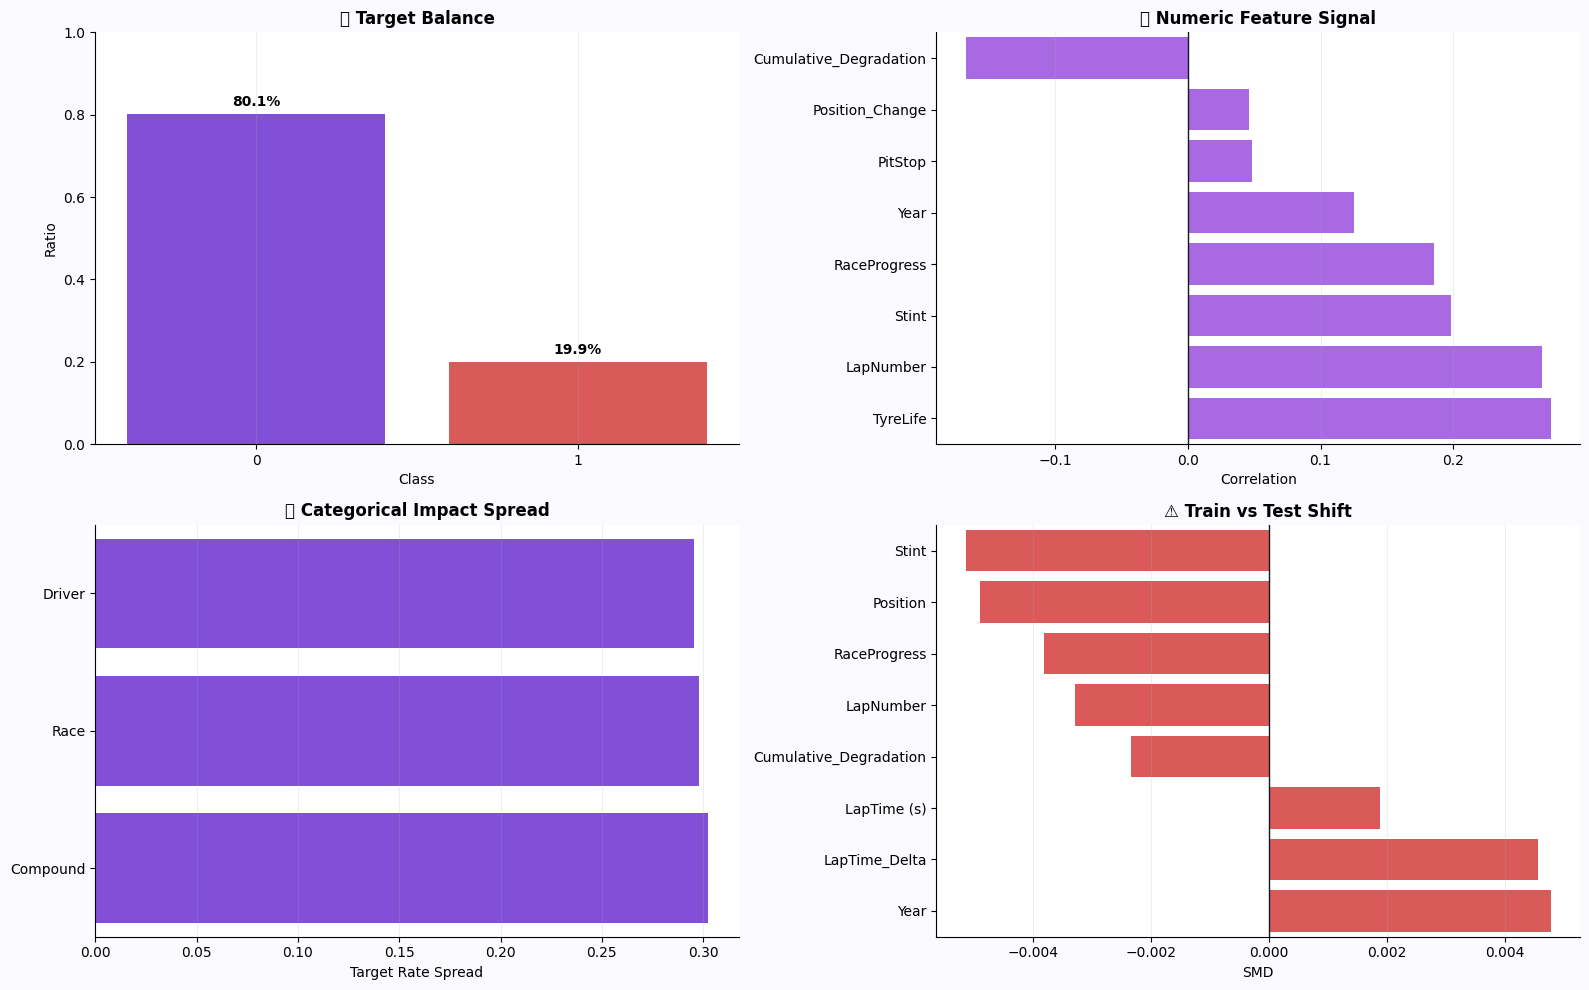

In [7]:

COLORS = {
    "primary": "#7C3AED",   # purple
    "risk": "#EF4444",      # red
    "signal": "#A855F7",    # bright purple
    "dark": "#111827",
    "bg": "#FAFAFF"
}

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

plt.style.use("default")

if "NUMERIC_SIGNAL" not in globals():
    NUMERIC_SIGNAL = point_biserial_screen(train, NUMS, TARGET)

if "CATEGORICAL_SIGNAL" not in globals():
    CATEGORICAL_OBSERVED_STATS = categorical_feature_stats(train, test, CATS, TARGET)
    CATEGORICAL_SIGNAL = CATEGORICAL_OBSERVED_STATS[[
        "Feature", "Spread"
    ]].copy()

if "NUMERIC_SHIFT" not in globals():
    NUMERIC_SHIFT = numeric_shift_table(train, test, NUMS)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.patch.set_facecolor(COLORS["bg"])

target_counts = (
    train[TARGET]
    .value_counts(normalize=True)
    .sort_index()
    .rename_axis(TARGET)
    .reset_index(name="Ratio")
)

sns.barplot(
    data=target_counts,
    x=TARGET,
    y="Ratio",
    hue=TARGET,
    ax=axes[0, 0],
    palette={0: COLORS["primary"], 1: COLORS["risk"]},
    legend=False
)

axes[0, 0].set_title("🎯 Target Balance", fontweight="bold")
axes[0, 0].set_ylim(0, 1)
axes[0, 0].set_xlabel("Class")
axes[0, 0].set_ylabel("Ratio")

for patch, val in zip(axes[0, 0].patches, target_counts["Ratio"]):
    axes[0, 0].text(
        patch.get_x() + patch.get_width() / 2,
        val + 0.02,
        f"{val:.1%}",
        ha="center",
        fontweight="bold"
    )


signal_plot = NUMERIC_SIGNAL.dropna().head(8).sort_values("Correlation")

sns.barplot(
    data=signal_plot,
    y="Feature",
    x="Correlation",
    ax=axes[0, 1],
    color=COLORS["signal"]
)

axes[0, 1].axvline(0, color=COLORS["dark"], linewidth=1)
axes[0, 1].set_title("📈 Numeric Feature Signal", fontweight="bold")
axes[0, 1].set_xlabel("Correlation")
axes[0, 1].set_ylabel("")

cat_plot = CATEGORICAL_SIGNAL.dropna().head(8).sort_values("Spread")

sns.barplot(
    data=cat_plot,
    y="Feature",
    x="Spread",
    ax=axes[1, 0],
    color=COLORS["primary"]
)

axes[1, 0].set_title("🧩 Categorical Impact Spread", fontweight="bold")
axes[1, 0].set_xlabel("Target Rate Spread")
axes[1, 0].set_ylabel("")

shift_plot = NUMERIC_SHIFT.dropna().head(8).sort_values("SMD")

sns.barplot(
    data=shift_plot,
    y="Feature",
    x="SMD",
    ax=axes[1, 1],
    color=COLORS["risk"]
)

axes[1, 1].axvline(0, color=COLORS["dark"], linewidth=1)
axes[1, 1].set_title("⚠️ Train vs Test Shift", fontweight="bold")
axes[1, 1].set_xlabel("SMD")
axes[1, 1].set_ylabel("")

for ax in axes.flat:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, axis="x", alpha=0.2)

plt.tight_layout()
plt.show()

### 4.1 Missing Values Analysis

Missingness determines whether imputation is a meaningful modeling choice or only a safety guard. The useful output here is the dataset-level check plus any original-reference columns that need special handling.

In [8]:

THEME = {
    "bg": "#F5F3FF",        # soft purple background
    "panel": "#EDE9FE",     # light violet card
    "accent": "#7C3AED",    # deep purple
    "muted": "#6B7280",
    "danger": "#EF4444",
    "text": "#111827"
}

datasets = {"Train": train, "Test": test}
if original is not None:
    datasets["Original"] = original

missing_rows = []

for name, df in datasets.items():
    total_cells = df.shape[0] * df.shape[1]
    total_missing = int(df.isna().sum().sum())

    missing_rows.append({
        "Dataset": name,
        "Rows": len(df),
        "Columns": df.shape[1],
        "Total_Missing": total_missing,
        "Columns_With_Missing": int((df.isna().sum() > 0).sum()),
        "Missing_Cell_Rate": round(total_missing / total_cells, 5) if total_cells else 0
    })

missing_df = pd.DataFrame(missing_rows)

def styled_card(title, df):
    html = f"""
    <div style="
        background:{THEME['panel']};
        border:1px solid {THEME['accent']};
        border-radius:16px;
        padding:18px;
        margin:12px 0;
        box-shadow:0 4px 15px rgba(124,58,237,0.15);
    ">
        <h3 style="color:{THEME['accent']}; margin-bottom:10px;">
            {title}
        </h3>
        {df.to_html(index=False)}
    </div>
    """
    from IPython.display import display, HTML
    display(HTML(html))


def styled_kv(title, items):
    html = f"""
    <div style="
        background:{THEME['panel']};
        border:1px solid {THEME['accent']};
        border-radius:16px;
        padding:16px;
        margin:12px 0;
        color:{THEME['text']};
    ">
        <h3 style="color:{THEME['accent']}; margin-bottom:10px;">{title}</h3>
    """
    for k, v in items:
        html += f"""
        <div style="display:flex; justify-content:space-between; margin:6px 0;">
            <span style="color:{THEME['muted']}">{k}</span>
            <span style="font-weight:600;">{v}</span>
        </div>
        """
    html += "</div>"

    from IPython.display import display, HTML
    display(HTML(html))

styled_card("💜 Missing Value Overview", missing_df)


if original is not None:
    original_missing = (
        original.isna()
        .sum()
        .rename("Missing_Count")
        .reset_index()
        .rename(columns={"index": "Feature"})
    )

    original_missing = original_missing[original_missing["Missing_Count"] > 0].copy()

    if len(original_missing):
        original_missing["Missing_Pct"] = original_missing["Missing_Count"] / len(original)
        original_missing = original_missing.sort_values("Missing_Pct", ascending=False)

        styled_card("🧪 Original Dataset Missing Columns", original_missing)
    else:
        styled_kv(
            "🧪 Original Dataset Clean",
            [("Missing Columns", "0")]
        )

Dataset,Rows,Columns,Total_Missing,Columns_With_Missing,Missing_Cell_Rate
Train,439140,16,0,0,0.0
Test,188165,15,0,0,0.0


### 4.2 Duplicate and ID Checks

This check verifies that row identity and duplicate structure do not create accidental leakage or submission-order risk.

In [9]:

THEME = {
    "bg": "#EFF6FF",        # soft blue background
    "panel": "#DBEAFE",     # light blue card
    "accent": "#2563EB",    # strong blue
    "muted": "#6B7280",
    "danger": "#EF4444",
    "text": "#111827"
}

duplicate_summary = pd.DataFrame({
    "Dataset": ["Train", "Test"],
    "Rows": [len(train), len(test)],

    "Duplicate_IDs": [
        train[ID_COL].duplicated().sum(),
        test[ID_COL].duplicated().sum()
    ],

    "Duplicate_Full_Rows": [
        train.duplicated().sum(),
        test.duplicated().sum()
    ],

    "Duplicate_Feature_Rows": [
        train[shared_feature_cols].duplicated().sum(),
        test[shared_feature_cols].duplicated().sum()
    ],
})

def blue_card(title, df):
    html = f"""
    <div style="
        background:{THEME['panel']};
        border:1px solid {THEME['accent']};
        border-radius:16px;
        padding:18px;
        margin:12px 0;
        box-shadow:0 4px 12px rgba(37,99,235,0.15);
    ">
        <h3 style="color:{THEME['accent']}; margin-bottom:10px;">
            {title}
        </h3>
        {df.to_html(index=False)}
    </div>
    """
    from IPython.display import display, HTML
    display(HTML(html))


def blue_kv(title, items):
    html = f"""
    <div style="
        background:{THEME['panel']};
        border:1px solid {THEME['accent']};
        border-radius:16px;
        padding:16px;
        margin:12px 0;
        color:{THEME['text']};
    ">
        <h3 style="color:{THEME['accent']}; margin-bottom:10px;">
            {title}
        </h3>
    """
    for k, v in items:
        html += f"""
        <div style="display:flex; justify-content:space-between; margin:6px 0;">
            <span style="color:{THEME['muted']}">{k}</span>
            <span style="font-weight:600;">{v}</span>
        </div>
        """
    html += "</div>"

    from IPython.display import display, HTML
    display(HTML(html))

blue_card("💙 Duplicate & ID Audit", duplicate_summary)

total_dup_train = train.duplicated().sum()
total_dup_test = test.duplicated().sum()

if total_dup_train == 0 and total_dup_test == 0:
    blue_kv(
        "🟢 Data Integrity Status",
        [("Status", "Clean - No duplicates detected")]
    )
else:
    blue_kv(
        "⚠️ Data Integrity Warning",
        [
            ("Train Duplicates", total_dup_train),
            ("Test Duplicates", total_dup_test)
        ]
    )

Dataset,Rows,Duplicate_IDs,Duplicate_Full_Rows,Duplicate_Feature_Rows
Train,439140,0,0,0
Test,188165,0,0,0


### 4.3 Cardinality and Support Check

Categorical cardinality shapes the encoding strategy. Low-cardinality fields can be one-hot encoded cleanly, while high-cardinality fields such as Driver need support-aware treatment in stronger models.

In [10]:

THEME = {
    "bg": "#ECFDF5",        # very light green background
    "panel": "#D1FAE5",     # soft green card
    "accent": "#10B981",    # emerald green
    "muted": "#6B7280",
    "text": "#111827",
    "warn": "#F59E0B"
}


cardinality_rows = []

for col in CATS:
    vc = train[col].value_counts(dropna=False)

    train_unique = train[col].nunique(dropna=True)
    test_unique = test[col].nunique(dropna=True)

    train_values = set(train[col].dropna().unique())
    test_values = set(test[col].dropna().unique())

    unseen = len(test_values - train_values)

    cardinality_rows.append({
        "Feature": col,
        "Train_Unique": train_unique,
        "Test_Unique": test_unique,
        "Smallest_Category_Count": int(vc.min()) if len(vc) else 0,
        "Largest_Category_Count": int(vc.max()) if len(vc) else 0,
        "Unseen_Test_Categories": unseen,
    })

cardinality_df = pd.DataFrame(cardinality_rows)

def green_card(title, df):
    html = f"""
    <div style="
        background:{THEME['panel']};
        border:1px solid {THEME['accent']};
        border-radius:16px;
        padding:18px;
        margin:12px 0;
        box-shadow:0 4px 12px rgba(16,185,129,0.15);
    ">
        <h3 style="color:{THEME['accent']}; margin-bottom:10px;">
            {title}
        </h3>
        {df.to_html(index=False)}
    </div>
    """
    from IPython.display import display, HTML
    display(HTML(html))


def green_kv(title, items):
    html = f"""
    <div style="
        background:{THEME['panel']};
        border:1px solid {THEME['accent']};
        border-radius:16px;
        padding:16px;
        margin:12px 0;
        color:{THEME['text']};
    ">
        <h3 style="color:{THEME['accent']}; margin-bottom:10px;">
            {title}
        </h3>
    """
    for k, v in items:
        html += f"""
        <div style="display:flex; justify-content:space-between; margin:6px 0;">
            <span style="color:{THEME['muted']}">{k}</span>
            <span style="font-weight:600;">{v}</span>
        </div>
        """
    html += "</div>"

    from IPython.display import display, HTML
    display(HTML(html))

green_card("💚 Categorical Cardinality & Support", cardinality_df)

high_cardinality = (cardinality_df["Train_Unique"] > 50).sum()
unseen_risky = (cardinality_df["Unseen_Test_Categories"] > 0).sum()

if unseen_risky == 0:
    green_kv(
        "🟢 Category Stability Status",
        [
            ("Unseen Categories", "None detected"),
            ("High Cardinality Features", high_cardinality)
        ]
    )
else:
    green_kv(
        "⚠️ Category Drift Warning",
        [
            ("Features with unseen categories", unseen_risky),
            ("High Cardinality Features", high_cardinality)
        ]
    )

Feature,Train_Unique,Test_Unique,Smallest_Category_Count,Largest_Category_Count,Unseen_Test_Categories
Driver,887,801,1,1682,0
Compound,5,5,1355,211141,0
Race,26,26,3185,24462,0


## 5. 🎯 Target and Feature Signal

<div style="background:#FFFCF8; border:1px solid #E2D8C7; border-left:6px solid #3D6F8A; border-radius:14px; padding:13px 15px; margin:10px 0 16px 0; color:#233127; line-height:1.58; box-shadow:0 8px 18px rgba(35,49,39,0.04);">This is the main evidence section. It asks which raw fields separate pit-next-lap rows from non-pit rows, and whether the separation is monotonic, categorical, or concentrated in specific race phases.</div>

### 5.1 Target Balance

The target is a probability problem, not a hard-label counting exercise. The positive rate is low enough that ROC-AUC, PR-AUC, log loss, and calibration are more informative than raw accuracy.

In [11]:
THEME = {
    "bg": "#FAFAFF",
    "panel": "#F3E8FF",
    "accent": "#7C3AED",   # purple
    "risk": "#EF4444",     # red
    "muted": "#6B7280",
    "text": "#111827"
}

target_distribution = (
    train[TARGET]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis(TARGET)
    .reset_index(name="Count")
)

target_distribution["Ratio"] = target_distribution["Count"] / len(train)
positive_count = int(target_distribution.loc[target_distribution[TARGET] == 1, "Count"].values[0])
negative_count = int(target_distribution.loc[target_distribution[TARGET] == 0, "Count"].values[0])

positive_rate = positive_count / len(train)
negative_rate = negative_count / len(train)

imbalance_ratio = negative_count / positive_count if positive_count != 0 else np.nan

def purple_card(title, df):
    html = f"""
    <div style="
        background:{THEME['panel']};
        border:1px solid {THEME['accent']};
        border-radius:16px;
        padding:18px;
        margin:12px 0;
        box-shadow:0 4px 12px rgba(124,58,237,0.15);
    ">
        <h3 style="color:{THEME['accent']}; margin-bottom:10px;">
            {title}
        </h3>
        {df.to_html(index=False)}
    </div>
    """
    from IPython.display import display, HTML
    display(HTML(html))


def kv_card(title, items):
    html = f"""
    <div style="
        background:{THEME['panel']};
        border:1px solid {THEME['accent']};
        border-radius:16px;
        padding:16px;
        margin:12px 0;
        color:{THEME['text']};
    ">
        <h3 style="color:{THEME['accent']}; margin-bottom:10px;">
            {title}
        </h3>
    """
    for k, v in items:
        html += f"""
        <div style="display:flex; justify-content:space-between; margin:6px 0;">
            <span style="color:{THEME['muted']}">{k}</span>
            <span style="font-weight:600;">{v}</span>
        </div>
        """
    html += "</div>"

    from IPython.display import display, HTML
    display(HTML(html))

kv_card("🎯 Target Balance Overview", [
    ("PitNextLap = 1", f"{positive_rate:.2%} ({positive_count:,})"),
    ("PitNextLap = 0", f"{negative_rate:.2%} ({negative_count:,})"),
    ("Imbalance Ratio", f"{imbalance_ratio:.2f}:1"),
])

purple_card("📊 Target Distribution Table", target_distribution)

if imbalance_ratio > 3:
    kv_card(
        "⚠️ Imbalance Warning",
        [
            ("Status", "Highly imbalanced dataset"),
            ("Recommendation", "Use class weights / focal loss / PR-AUC"),
        ]
    )
else:
    kv_card(
        "🟢 Balance Status",
        [
            ("Status", "Moderately balanced dataset"),
            ("Recommendation", "Standard classifiers acceptable"),
        ]
    )

PitNextLap,Count,Ratio
0,351759,0.801018
1,87381,0.198982


### 5.2 Numeric Summary by Target

This compact table compares average numeric state by target class. It is a direction check: large mean differences suggest useful signal, while small differences may still matter through nonlinear or interaction effects.

In [12]:

THEME = {
    "bg": "#FFFBEB",        # soft yellow background
    "panel": "#FEF3C7",     # light amber card
    "accent": "#F59E0B",    # strong yellow-orange
    "muted": "#6B7280",
    "text": "#111827"
}

summary_features = [feature for feature in NUMS if feature != "Year"]

summary_rows = []

for feature in summary_features:
    grouped = train.groupby(TARGET)[feature]

    mean_0 = grouped.mean().get(0, np.nan)
    mean_1 = grouped.mean().get(1, np.nan)

    summary_rows.append({
        "Feature": feature,
        "PitNextLap=0 Mean": mean_0,
        "PitNextLap=1 Mean": mean_1,
        "Mean Difference": mean_1 - mean_0,
    })

numeric_by_target = pd.DataFrame(summary_rows)

for col in ["PitNextLap=0 Mean", "PitNextLap=1 Mean", "Mean Difference"]:
    numeric_by_target[col] = numeric_by_target[col].round(2)

def yellow_card(title, df):
    html = f"""
    <div style="
        background:{THEME['panel']};
        border:1px solid {THEME['accent']};
        border-radius:16px;
        padding:18px;
        margin:12px 0;
        box-shadow:0 4px 12px rgba(245,158,11,0.15);
    ">
        <h3 style="color:{THEME['accent']}; margin-bottom:10px;">
            {title}
        </h3>
        {df.to_html(index=False)}
    </div>
    """
    from IPython.display import display, HTML
    display(HTML(html))


def yellow_kv(title, items):
    html = f"""
    <div style="
        background:{THEME['panel']};
        border:1px solid {THEME['accent']};
        border-radius:16px;
        padding:16px;
        margin:12px 0;
        color:{THEME['text']};
    ">
        <h3 style="color:{THEME['accent']}; margin-bottom:10px;">
            {title}
        </h3>
    """
    for k, v in items:
        html += f"""
        <div style="display:flex; justify-content:space-between; margin:6px 0;">
            <span style="color:{THEME['muted']}">{k}</span>
            <span style="font-weight:600;">{v}</span>
        </div>
        """
    html += "</div>"

    from IPython.display import display, HTML
    display(HTML(html))
yellow_card("💛 Numeric Mean Difference by Target", numeric_by_target)
top_feature = numeric_by_target.loc[numeric_by_target["Mean Difference"].abs().idxmax()]

yellow_kv(
    "📌 Key Insight",
    [
        ("Strongest Feature", top_feature["Feature"]),
        ("Mean Difference", f"{top_feature['Mean Difference']:.2f}"),
        ("Interpretation", "Higher separation → stronger predictive power")
    ]
)

Feature,PitNextLap=0 Mean,PitNextLap=1 Mean,Mean Difference
PitStop,0.13,0.17,0.04
LapNumber,20.85,32.19,11.34
Stint,1.70,2.17,0.47
TyreLife,12.82,19.54,6.71
Position,9.57,9.86,0.28
LapTime (s),91.28,89.60,-1.69
LapTime_Delta,-3.66,-4.21,-0.54
Cumulative_Degradation,-21.15,-44.12,-22.96
RaceProgress,0.31,0.43,0.12
Position_Change,0.01,0.47,0.46


### 5.3 Numeric Distribution Panels

The plots use feature-aware geometry: discrete variables are shown as bars or binned rates, while continuous variables use density views with outlier-resistant axes. This avoids implying impossible values such as fractional years or fractional stints.

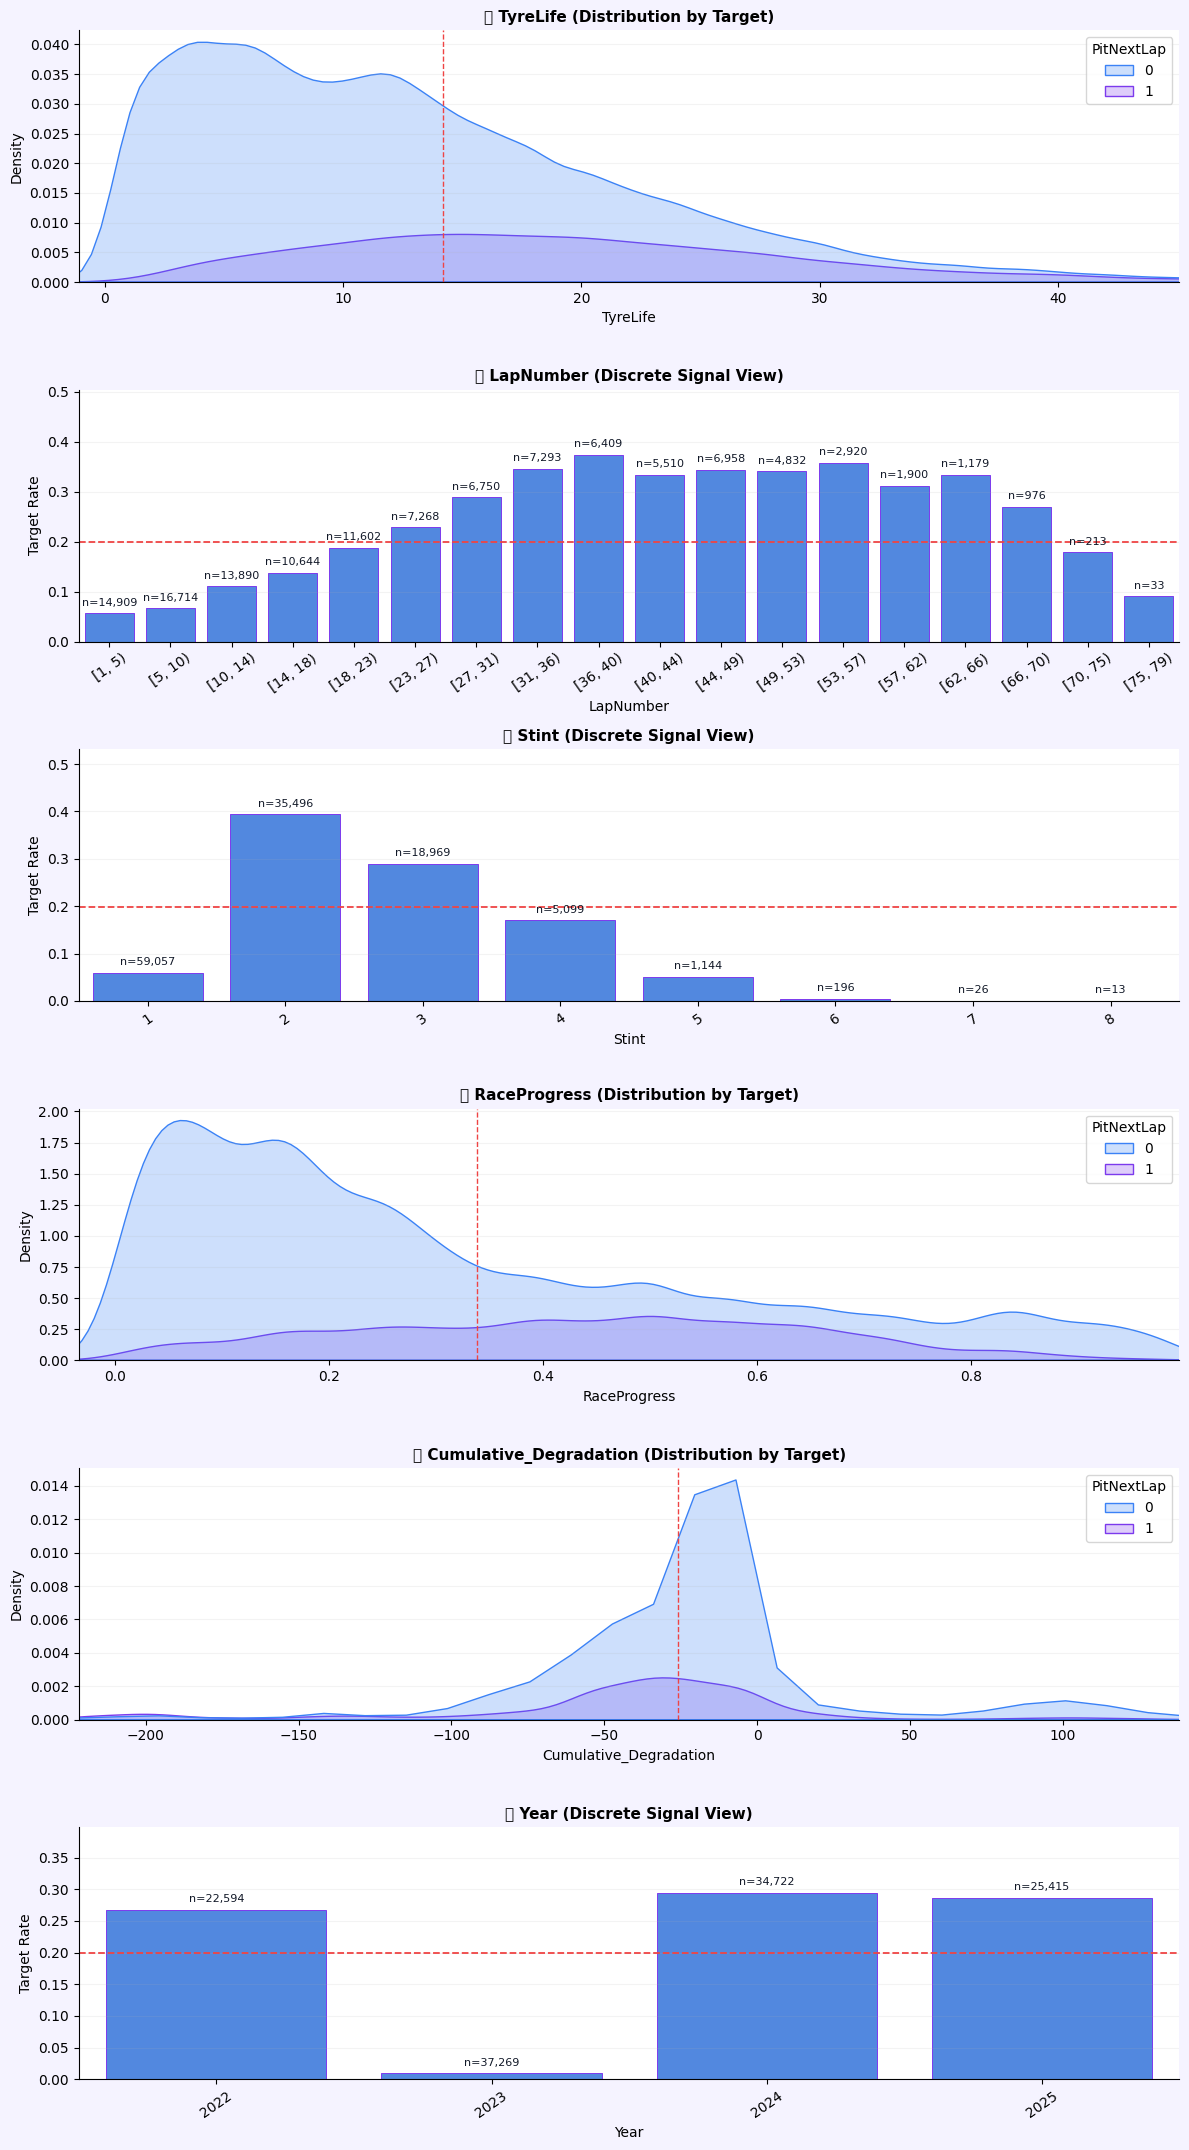

In [13]:
COLORS = {
    "primary": "#3B82F6",   # blue (signal structure)
    "accent": "#7C3AED",    # purple (importance)
    "risk": "#EF4444",      # red (baseline reference)
    "dark": "#111827",
    "muted": "#6B7280",
    "bg": "#F5F3FF"
}

plot_train = safe_sample(train)
top_numeric = NUMERIC_SIGNAL["Feature"].head(6).tolist()

def is_discrete_numeric(series: pd.Series, max_unique: int = 30) -> bool:
    values = pd.to_numeric(series.dropna(), errors="coerce")
    if values.empty:
        return True
    integer_like = np.all(np.isclose(values, np.round(values)))
    return bool(integer_like and values.nunique() <= max_unique)
def add_bar_labels(ax, grouped, count_col="Support"):
    ymax = grouped["Target_Rate"].max() if len(grouped) else 0

    for patch, count in zip(ax.patches, grouped[count_col]):
        height = patch.get_height()
        ax.text(
            patch.get_x() + patch.get_width() / 2,
            height + max(0.005, ymax * 0.03),
            f"n={int(count):,}",
            ha="center",
            va="bottom",
            fontsize=8,
            color=COLORS["dark"]
        )

def plot_discrete_target_rate(ax, df, feature, target_col, max_levels: int = 18):
    tmp = df[[feature, target_col]].dropna().copy()
    tmp[feature] = pd.to_numeric(tmp[feature], errors="coerce")
    tmp = tmp.dropna()

    n_unique = tmp[feature].nunique()

    if n_unique > max_levels:
        integer_like = np.all(np.isclose(tmp[feature], np.round(tmp[feature])))

        if integer_like:
            min_v = int(np.floor(tmp[feature].min()))
            max_v = int(np.ceil(tmp[feature].max()))

            bins = np.linspace(min_v, max_v + 1, min(max_levels, max_v - min_v + 1) + 1)
            bins = np.unique(np.round(bins).astype(int))

            tmp["bin"] = pd.cut(tmp[feature], bins=bins, include_lowest=True, right=False)
            grouped = tmp.groupby("bin")[target_col].agg(Target_Rate="mean", Support="count").reset_index()

            grouped["Label"] = grouped["bin"].astype(str)

        else:
            tmp["bin"] = pd.cut(tmp[feature], bins=max_levels, duplicates="drop")
            grouped = tmp.groupby("bin")[target_col].agg(Target_Rate="mean", Support="count").reset_index()
            grouped["Label"] = grouped["bin"].astype(str)

        x_col = "Label"

    else:
        grouped = tmp.groupby(feature)[target_col].agg(Target_Rate="mean", Support="count").reset_index()
        grouped = grouped.sort_values(feature)
        grouped["Label"] = grouped[feature].astype(str)
        x_col = "Label"

    sns.barplot(
        data=grouped,
        x=x_col,
        y="Target_Rate",
        ax=ax,
        color=COLORS["primary"],
        edgecolor=COLORS["accent"],
        linewidth=0.7
    )

    ax.axhline(train[TARGET].mean(), color=COLORS["risk"], linestyle="--", linewidth=1.3)

    add_bar_labels(ax, grouped)

    ax.set_title(f"💜 {feature} (Discrete Signal View)", fontsize=11, fontweight="bold")
    ax.set_xlabel(feature)
    ax.set_ylabel("Target Rate")
    ax.tick_params(axis="x", rotation=35)
    ax.set_ylim(0, min(1.0, grouped["Target_Rate"].max() * 1.35))
def plot_continuous_density(ax, df, feature, target_col, lower_q=0.01, upper_q=0.99):
    tmp = df[[feature, target_col]].dropna().copy()
    tmp[feature] = pd.to_numeric(tmp[feature], errors="coerce")
    tmp = tmp.dropna()

    x_min, x_max = tmp[feature].quantile([lower_q, upper_q])

    if not np.isfinite(x_min) or not np.isfinite(x_max) or x_min == x_max:
        x_min, x_max = tmp[feature].min(), tmp[feature].max()

    pad = (x_max - x_min) * 0.05 if x_max > x_min else 1

    sns.kdeplot(
        data=tmp,
        x=feature,
        hue=tmp[target_col].astype(str),
        fill=True,
        alpha=0.25,
        ax=ax,
        palette=[COLORS["primary"], COLORS["accent"]]
    )

    ax.axvline(tmp[feature].mean(), color=COLORS["risk"], linestyle="--", linewidth=1)

    ax.set_xlim(x_min - pad, x_max + pad)
    ax.set_title(f"💙 {feature} (Distribution by Target)", fontsize=11, fontweight="bold")
    ax.set_xlabel(feature)
    ax.set_ylabel("Density")

if top_numeric:
    fig, axes = plt.subplots(len(top_numeric), 1, figsize=(12, 3.6 * len(top_numeric)))
    fig.patch.set_facecolor(COLORS["bg"])

    if len(top_numeric) == 1:
        axes = [axes]

    for ax, col in zip(axes, top_numeric):
        if is_discrete_numeric(plot_train[col]) or col in {"Year", "Stint", "PitStop", "LapNumber", "Position"}:
            plot_discrete_target_rate(ax, plot_train, col, TARGET)
        else:
            plot_continuous_density(ax, plot_train, col, TARGET)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.grid(True, axis="y", alpha=0.15)

    plt.tight_layout()
    plt.show()

else:
    display_note_card("Plot Status", "No numeric features available for visualization.")

### 5.4 Categorical Target Rates

Categorical signal is read through support-filtered target rates and spread, not through crowded name-by-name axes. For high-cardinality fields, the distribution of rates is more useful than a plot of every label.

Driver,887,350,439,13.18%,19.34%,42.75%


D198,13.18%,584,0.13%
D186,13.33%,645,0.15%
D201,13.37%,546,0.12%
D218,13.40%,470,0.11%
D179,13.62%,668,0.15%
D199,13.98%,565,0.13%
D213,14.29%,532,0.12%
D191,14.29%,602,0.14%
STR,42.75%,"1,275",0.29%
BEA,40.00%,555,0.13%
ALO,39.32%,"1,386",0.32%


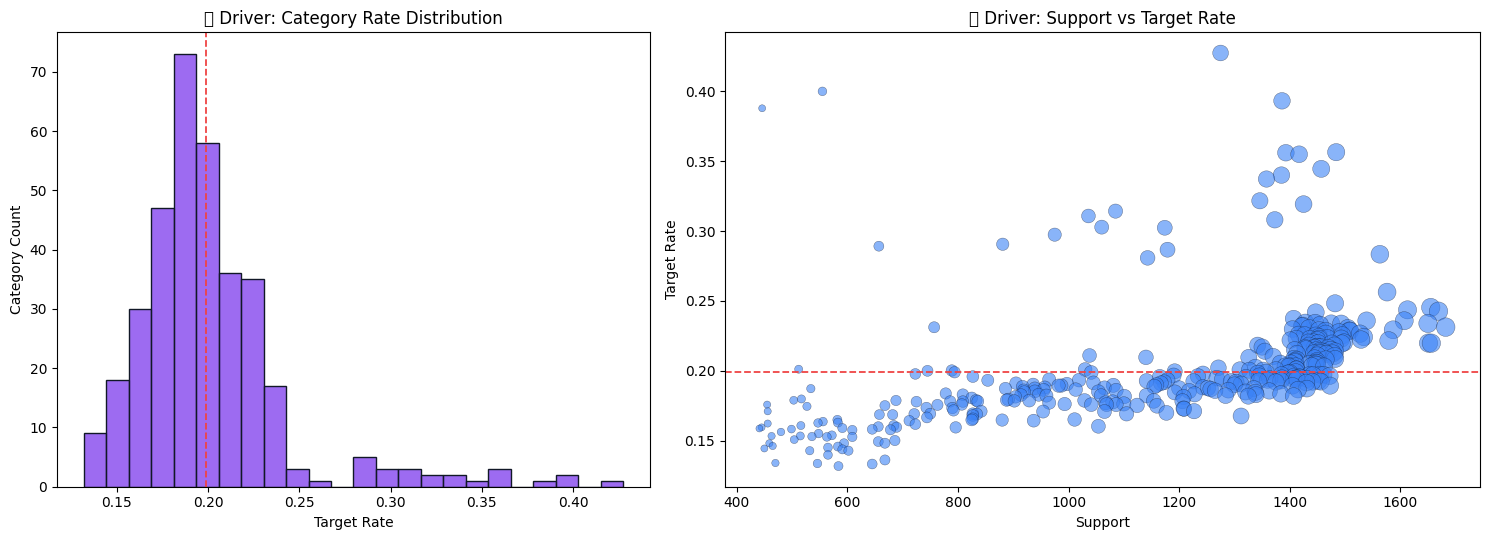

🌧️ WET,2.51%,"1,355",0.31%,1
🟡 MEDIUM,10.11%,"211,141",48.08%,1
🌦️ INTERMEDIATE,15.23%,"17,382",3.96%,1
🔴 SOFT,19.35%,"38,744",8.82%,1
🧱 HARD,32.75%,"170,518",38.83%,1


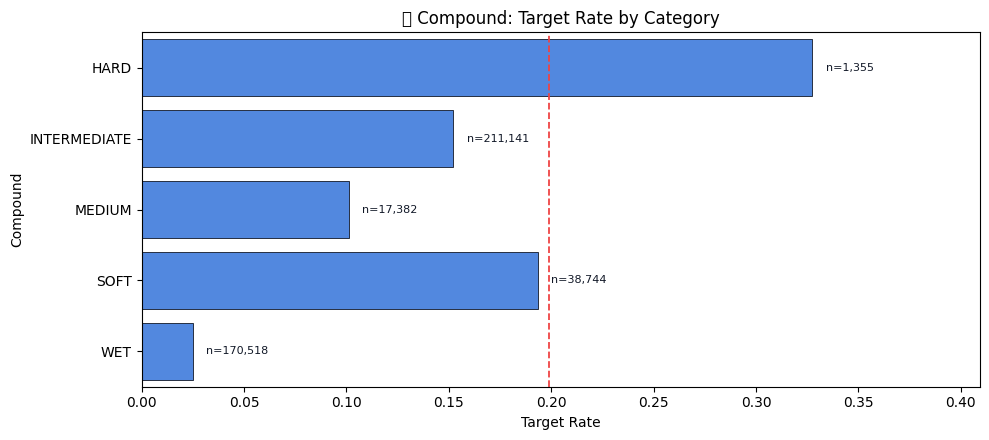

Mexico City Grand Prix,9.07%,"23,672",5.39%,1
Miami Grand Prix,10.36%,"18,860",4.29%,1
United States Grand Prix,11.40%,"18,045",4.11%,1
Italian Grand Prix,13.20%,"19,854",4.52%,1
British Grand Prix,13.35%,"15,383",3.50%,1
Singapore Grand Prix,14.18%,"18,960",4.32%,1
Pre-Season Testing,14.65%,"22,492",5.12%,1
Abu Dhabi Grand Prix,15.05%,"16,427",3.74%,1
Canadian Grand Prix,15.39%,"21,416",4.88%,1
Qatar Grand Prix,17.56%,"13,817",3.15%,1
Dutch Grand Prix,17.61%,"24,462",5.57%,1


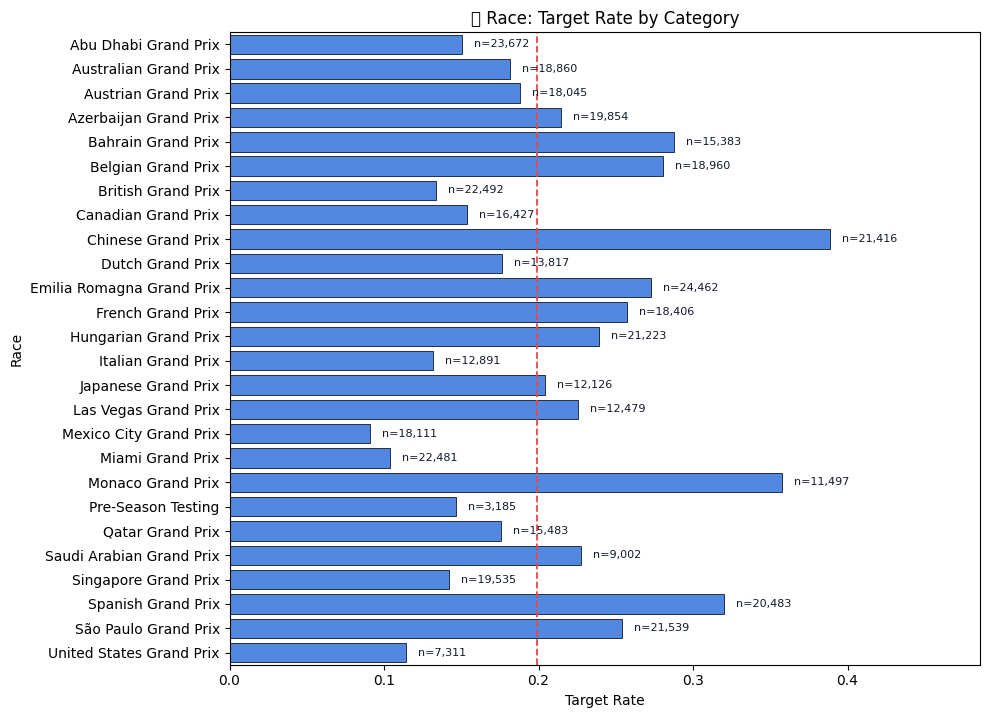

In [14]:
COLORS = {
    "primary": "#3B82F6",   # blue (structure / distribution)
    "accent": "#7C3AED",    # purple (importance / signal)
    "risk": "#EF4444",      # red (baseline reference)
    "dark": "#111827",
    "muted": "#6B7280",
    "bg": "#F5F3FF"
}

CATEGORY_SUPPORT_FLOOR = max(300, int(0.001 * len(train)))
HIGH_CARDINALITY_THRESHOLD = 40

def categorical_rate_table(df: pd.DataFrame, feature: str, target_col: str) -> pd.DataFrame:
    rates = (
        df.groupby(feature, observed=False, dropna=False)[target_col]
        .agg(Target_Rate="mean", Support="count")
        .reset_index()
        .sort_values("Target_Rate", ascending=False)
    )

    rates["Support_Share"] = rates["Support"] / len(df)
    rates["Stable_Support"] = rates["Support"] >= CATEGORY_SUPPORT_FLOOR

    return rates
def add_horizontal_support_labels(ax, table, support_col="Support"):
    xmax = table["Target_Rate"].max() if len(table) else 0

    for patch, support in zip(ax.patches, table[support_col]):
        width = patch.get_width()

        ax.text(
            width + max(0.003, xmax * 0.02),
            patch.get_y() + patch.get_height() / 2,
            f"n={int(support):,}",
            va="center",
            ha="left",
            fontsize=8,
            color=COLORS["dark"]
        )

def plot_readable_category_rates(feature: str, rates: pd.DataFrame):
    stable = rates[rates["Stable_Support"]].copy()

    if stable.empty:
        stable = rates.copy()
    if rates[feature].nunique() > HIGH_CARDINALITY_THRESHOLD:

        display_note_card(
            f"💜 {feature}: High Cardinality Feature",
            f"""
            This feature has {rates[feature].nunique():,} unique categories.

            Visualization shows:
            - Only statistically stable categories (support-filtered)
            - Distribution of category effects (not raw labels)

            Interpretation:
            Treat this as a STRUCTURAL SIGNAL feature, not semantic ranking.
            """,
            accent=COLORS["accent"]
        )

        summary = pd.DataFrame([{
            "Feature": feature,
            "Total_Categories": rates[feature].nunique(),
            "Stable_Categories": stable[feature].nunique(),
            "Support_Floor": CATEGORY_SUPPORT_FLOOR,
            "Min_Stable_Rate": stable["Target_Rate"].min(),
            "Median_Stable_Rate": stable["Target_Rate"].median(),
            "Max_Stable_Rate": stable["Target_Rate"].max(),
        }])

        display_table_card(f"📊 {feature} Summary", summary, index=False)

        # Top / Bottom categories
        low = stable.nsmallest(8, "Target_Rate")
        high = stable.nlargest(8, "Target_Rate")

        extremes = pd.concat([low, high]).drop_duplicates(subset=[feature])

        display_table_card(
            f"📌 {feature} Extreme Categories",
            extremes[[feature, "Target_Rate", "Support", "Support_Share"]],
            index=False
        )
        fig, axes = plt.subplots(
            1, 2,
            figsize=(15, 5.5),
            gridspec_kw={"width_ratios": [1.1, 1.4]}
        )

        # Histogram of rates
        sns.histplot(
            data=stable,
            x="Target_Rate",
            bins=24,
            ax=axes[0],
            color=COLORS["accent"],
            edgecolor=COLORS["dark"]
        )

        axes[0].axvline(train[TARGET].mean(), color=COLORS["risk"], linestyle="--", linewidth=1.3)
        axes[0].set_title(f"💜 {feature}: Category Rate Distribution")
        axes[0].set_xlabel("Target Rate")
        axes[0].set_ylabel("Category Count")

        # Support vs rate scatter
        sns.scatterplot(
            data=stable,
            x="Support",
            y="Target_Rate",
            size="Support",
            sizes=(25, 180),
            alpha=0.6,
            color=COLORS["primary"],
            edgecolor=COLORS["dark"],
            linewidth=0.3,
            ax=axes[1],
            legend=False
        )

        axes[1].axhline(train[TARGET].mean(), color=COLORS["risk"], linestyle="--", linewidth=1.3)
        axes[1].set_title(f"💙 {feature}: Support vs Target Rate")
        axes[1].set_xlabel("Support")
        axes[1].set_ylabel("Target Rate")

        plt.tight_layout()
        plt.show()

        return
    plot_rates = rates.sort_values("Target_Rate", ascending=True)

    display_table_card(
        f"📊 {feature}: Target Rate by Category",
        plot_rates[[feature, "Target_Rate", "Support", "Support_Share", "Stable_Support"]],
        index=False
    )

    fig, ax = plt.subplots(
        figsize=(10, max(4.5, 0.28 * len(plot_rates)))
    )

    sns.barplot(
        data=plot_rates,
        y=feature,
        x="Target_Rate",
        ax=ax,
        color=COLORS["primary"],
        edgecolor=COLORS["dark"],
        linewidth=0.6
    )

    ax.axvline(train[TARGET].mean(), color=COLORS["risk"], linestyle="--", linewidth=1.3)

    add_horizontal_support_labels(ax, plot_rates)

    ax.set_title(f"💙 {feature}: Target Rate by Category")
    ax.set_xlabel("Target Rate")
    ax.set_ylabel(feature)
    ax.set_xlim(0, min(1.0, max(0.35, plot_rates["Target_Rate"].max() * 1.25)))

    plt.tight_layout()
    plt.show()

for col in CATS:
    rates = categorical_rate_table(train, col, TARGET)
    plot_readable_category_rates(col, rates)

## 6. 🧪 Train/Test Stability

<div style="background:#FFFCF8; border:1px solid #E2D8C7; border-left:6px solid #C7772C; border-radius:14px; padding:13px 15px; margin:10px 0 16px 0; color:#233127; line-height:1.58; box-shadow:0 8px 18px rgba(35,49,39,0.04);">A feature can be predictive and still risky if its train/test distribution shifts. These checks look for numeric drift, unseen categories, and original-reference prior differences before the baseline model is built.</div>

### 6.1 Numeric Train/Test Shift

Standardized mean difference puts numeric train/test drift on a comparable scale. Small values support a simple first validation split; larger values would require more cautious stress testing.

Stint,1.7891,1.7842,-0.0051
Position,9.6303,9.6045,-0.0049
RaceProgress,0.3377,0.3367,-0.0038
LapNumber,23.1059,23.0502,-0.0033
Cumulative_Degradation,-25.7218,-25.8495,-0.0023
TyreLife,14.1582,14.1606,0.0002
PitStop,0.1361,0.1363,0.0004
Position_Change,0.1015,0.1068,0.0013
LapTime (s),90.9487,90.9869,0.0019
LapTime_Delta,-3.7700,-3.5778,0.0046
Year,"2,023.5235","2,023.5284",0.0048


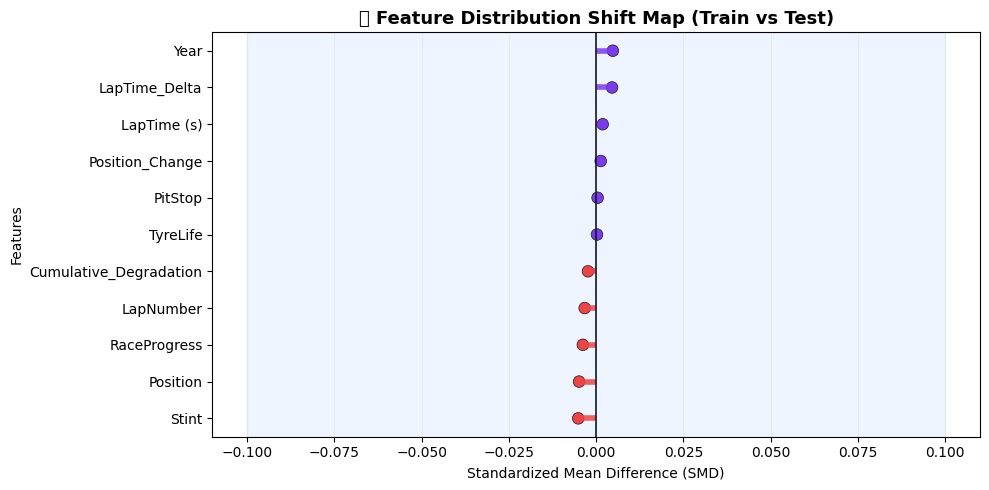

In [15]:
COLORS = {
    "pos": "#7C3AED",      # purple (positive shift)
    "neg": "#EF4444",      # red (negative shift)
    "neutral": "#3B82F6",  # blue (stable zone)
    "dark": "#111827",
    "bg": "#F5F3FF"
}

display_table_card(
    "📊 Numeric Train/Test Shift (SMD)",
    NUMERIC_SHIFT.drop(columns=["Abs_SMD"]).sort_values("SMD"),
    index=False
)

shift_df = NUMERIC_SHIFT.dropna().sort_values("SMD")

plt.figure(figsize=(10, max(5, 0.38 * len(shift_df))))

# Stable reference band
plt.axvspan(-0.1, 0.1, color=COLORS["neutral"], alpha=0.08, label="Stable Zone")

# Diverging bars
colors = [
    COLORS["pos"] if val > 0 else COLORS["neg"]
    for val in shift_df["SMD"]
]

plt.hlines(
    y=shift_df["Feature"],
    xmin=0,
    xmax=shift_df["SMD"],
    color=colors,
    linewidth=4,
    alpha=0.85
)

# Dots at endpoints (emphasize magnitude)
plt.scatter(
    shift_df["SMD"],
    shift_df["Feature"],
    color=colors,
    s=70,
    edgecolor=COLORS["dark"],
    linewidth=0.5
)

# Zero reference line
plt.axvline(0, color=COLORS["dark"], linewidth=1.2)

# Labels
plt.title("🌈 Feature Distribution Shift Map (Train vs Test)", fontsize=13, fontweight="bold")
plt.xlabel("Standardized Mean Difference (SMD)")
plt.ylabel("Features")

plt.grid(axis="x", alpha=0.15)

plt.tight_layout()
plt.show()

### 6.2 Categorical Train/Test Coverage

Coverage checks whether test contains unseen category levels and whether train/test category support is broadly aligned. This matters most for high-cardinality fields and one-hot encoders.

In [16]:
COLORS = {
    "ok": "#10B981",      # green (safe / stable)
    "warn": "#F59E0B",    # amber (risk)
    "bad": "#EF4444",     # red (drift)
    "bg": "#ECFDF5",      # light green background
    "text": "#111827",
    "muted": "#6B7280"
}

coverage_rows = []

for col in CATS:
    train_values = set(train[col].dropna().unique())
    test_values = set(test[col].dropna().unique())

    unseen_values = sorted(list(test_values - train_values))

    coverage_rows.append({
        "Feature": col,
        "Train_Unique": len(train_values),
        "Test_Unique": len(test_values),
        "Unseen_In_Test": len(unseen_values),
        "Unseen_Examples": ", ".join(map(str, unseen_values[:8])) if unseen_values else "None"
    })

coverage_df = pd.DataFrame(coverage_rows)

coverage_df["Risk_Level"] = coverage_df["Unseen_In_Test"].apply(
    lambda x: "High" if x > 20 else ("Medium" if x > 0 else "Low")
)

def green_table(title, df):
    html = f"""
    <div style="
        background:{COLORS['bg']};
        border:1px solid {COLORS['ok']};
        border-radius:16px;
        padding:18px;
        margin:12px 0;
        box-shadow:0 4px 12px rgba(16,185,129,0.12);
    ">
        <h3 style="color:{COLORS['ok']}; margin-bottom:10px;">
            💚 {title}
        </h3>
        {df.to_html(index=False)}
    </div>
    """
    from IPython.display import display, HTML
    display(HTML(html))


def green_kv(title, items):
    html = f"""
    <div style="
        background:{COLORS['bg']};
        border:1px solid {COLORS['ok']};
        border-radius:16px;
        padding:16px;
        margin:12px 0;
        color:{COLORS['text']};
    ">
        <h3 style="color:{COLORS['ok']}; margin-bottom:10px;">
            💚 {title}
        </h3>
    """
    for k, v in items:
        html += f"""
        <div style="display:flex; justify-content:space-between; margin:6px 0;">
            <span style="color:{COLORS['muted']}">{k}</span>
            <span style="font-weight:600;">{v}</span>
        </div>
        """
    html += "</div>"

    from IPython.display import display, HTML
    display(HTML(html))

green_table("Categorical Train/Test Coverage", coverage_df)

total_unseen = coverage_df["Unseen_In_Test"].sum()
risky_features = (coverage_df["Unseen_In_Test"] > 0).sum()

if risky_features == 0:
    green_kv(
        "🟢 Coverage Health Status",
        [
            ("Status", "Perfect generalization coverage"),
            ("Unseen Categories", "None"),
            ("Risk Level", "Low across all features")
        ]
    )
else:
    green_kv(
        "⚠️ Coverage Risk Summary",
        [
            ("Features with unseen values", risky_features),
            ("Total unseen categories", total_unseen),
            ("Recommendation", "Use encoding fallback / unknown bucket handling")
        ]
    )

Feature,Train_Unique,Test_Unique,Unseen_In_Test,Unseen_Examples,Risk_Level
Driver,887,801,0,None,Low
Compound,5,5,0,None,Low
Race,26,26,0,None,Low


### 6.3 Original Reference Snapshot

The original reference file is useful context, but its target prior can differ from the synthetic competition train set. Treat it as an ablation source rather than automatic extra training data.

In [17]:
COLORS = {
    "accent": "#7C3AED",   # purple (reference / lineage)
    "bg": "#F5F3FF",       # light purple background
    "text": "#111827",
    "muted": "#6B7280",
    "risk": "#EF4444"
}

if original is not None:

    original_summary = pd.DataFrame({
        "Dataset": ["Train", "Original"],
        "Rows": [len(train), len(original)],
        "Columns": [train.shape[1], original.shape[1]],
        "Target_Rate": [
            train[TARGET].mean(),
            original[TARGET].mean() if TARGET in original.columns else np.nan
        ],
    })

    def purple_card(title, df):
        html = f"""
        <div style="
            background:{COLORS['bg']};
            border:1px solid {COLORS['accent']};
            border-radius:16px;
            padding:18px;
            margin:12px 0;
            box-shadow:0 4px 12px rgba(124,58,237,0.12);
        ">
            <h3 style="color:{COLORS['accent']}; margin-bottom:10px;">
                💜 {title}
            </h3>
            {df.to_html(index=False)}
        </div>
        """
        from IPython.display import display, HTML
        display(HTML(html))


    def purple_kv(title, items):
        html = f"""
        <div style="
            background:{COLORS['bg']};
            border:1px solid {COLORS['accent']};
            border-radius:16px;
            padding:16px;
            margin:12px 0;
            color:{COLORS['text']};
        ">
            <h3 style="color:{COLORS['accent']}; margin-bottom:10px;">
                💜 {title}
            </h3>
        """
        for k, v in items:
            html += f"""
            <div style="display:flex; justify-content:space-between; margin:6px 0;">
                <span style="color:{COLORS['muted']}">{k}</span>
                <span style="font-weight:600;">{v}</span>
            </div>
            """
        html += "</div>"

        from IPython.display import display, HTML
        display(HTML(html))
    purple_card("Original Reference Comparison", original_summary)

    purple_card(
        "Original Schema Preview (Top 25 Rows)",
        schema_summary(original).head(25)
    )
    train_rate = train[TARGET].mean()
    original_rate = original[TARGET].mean() if TARGET in original.columns else np.nan

    if np.isfinite(original_rate):
        diff = abs(train_rate - original_rate)

        if diff < 0.01:
            status = "Highly aligned reference dataset"
        elif diff < 0.03:
            status = "Moderately aligned dataset"
        else:
            status = "Distribution shift detected"

        purple_kv(
            "📌 Reference Alignment Insight",
            [
                ("Train Target Rate", f"{train_rate:.2%}"),
                ("Original Target Rate", f"{original_rate:.2%}"),
                ("Absolute Difference", f"{diff:.4f}"),
                ("Assessment", status)
            ]
        )

else:
    def purple_kv(title, items):
        from IPython.display import display, HTML
        html = f"""
        <div style="
            background:{COLORS['bg']};
            border:1px solid {COLORS['accent']};
            border-radius:16px;
            padding:16px;
            margin:12px 0;
            color:{COLORS['text']};
        ">
            <h3 style="color:{COLORS['accent']}; margin-bottom:10px;">
                💜 {title}
            </h3>
        """
        for k, v in items:
            html += f"""
            <div style="display:flex; justify-content:space-between; margin:6px 0;">
                <span style="color:{COLORS['muted']}">{k}</span>
                <span style="font-weight:600;">{v}</span>
            </div>
            """
        html += "</div>"
        display(HTML(html))

    purple_kv(
        "Original Reference",
        [("Status", "No original/reference dataset loaded")]
    )

## 7. 🛠️ Feature Preparation

<div style="background:#FFFCF8; border:1px solid #E2D8C7; border-left:6px solid #2F6B4F; border-radius:14px; padding:13px 15px; margin:10px 0 16px 0; color:#233127; line-height:1.58; box-shadow:0 8px 18px rgba(35,49,39,0.04);">The baseline model receives only low-risk, interpretable racing-state features. These features express tyre age, remaining race phase, stint pressure, compound pressure, and recent pace changes without using the target.</div>

### 7.1 Add Racing-State and Interaction Features

The engineered fields convert raw lap state into relative pressure signals: estimated race length, remaining laps, tyre-life ratios, compound-adjusted tyre age, and position/lap-time movement.

In [18]:
COLORS = {
    "blue": "#3B82F6",
    "purple": "#7C3AED",
    "red": "#EF4444",
    "bg": "#F5F3FF",
    "text": "#111827",
    "muted": "#6B7280"
}

COMPOUND_HARDNESS_MAP = {
    "WET": 0.0,
    "INTERMEDIATE": 0.5,
    "SOFT": 1.0,
    "MEDIUM": 2.0,
    "HARD": 3.0,
}

def add_basic_features(df: pd.DataFrame) -> pd.DataFrame:
    data = df.copy()
    eps = 1e-6

    if {"LapNumber", "RaceProgress"}.issubset(data.columns):
        race_progress = data["RaceProgress"].clip(lower=eps)
        data["EstimatedRaceLaps"] = np.rint(data["LapNumber"] / race_progress).astype("Int64")
        data["RemainingRaceProgress"] = 1 - data["RaceProgress"]
        data["LapsRemainingEstimate"] = (data["EstimatedRaceLaps"] - data["LapNumber"]).astype("Int64")

    if {"TyreLife", "LapNumber"}.issubset(data.columns):
        data["TyreLifeToLapNumber"] = data["TyreLife"] / data["LapNumber"].replace(0, np.nan)
        data["TyreLifeMinusLapNumber"] = data["TyreLife"] - data["LapNumber"]

    if {"TyreLife", "EstimatedRaceLaps"}.issubset(data.columns):
        data["TyreLifeRaceFraction"] = data["TyreLife"] / data["EstimatedRaceLaps"].replace(0, np.nan)

    if {"TyreLife", "RaceProgress"}.issubset(data.columns):
        data["RaceProgress_x_TyreLife"] = data["RaceProgress"] * data["TyreLife"]

    if {"Stint", "TyreLife"}.issubset(data.columns):
        data["Stint_x_TyreLife"] = data["Stint"] * data["TyreLife"]

    if {"Stint", "RaceProgress"}.issubset(data.columns):
        data["Stint_x_RaceProgress"] = data["Stint"] * data["RaceProgress"]

    if "Compound" in data.columns:
        compound_hardness = data["Compound"].astype(str).map(COMPOUND_HARDNESS_MAP)

        data["CompoundHardness"] = compound_hardness

        if "TyreLife" in data.columns:
            data["TyreLife_x_CompoundHardness"] = data["TyreLife"] * compound_hardness

        if {"TyreLife", "RaceProgress"}.issubset(data.columns):
            data["StopUrgency"] = data["TyreLife"] * data["RaceProgress"] * compound_hardness

    if "Position_Change" in data.columns:
        data["PositionChangeDirection"] = np.sign(data["Position_Change"].fillna(0))
        data["AbsPositionChange"] = data["Position_Change"].abs()

    if "LapTime_Delta" in data.columns:
        data["AbsLapTimeDelta"] = data["LapTime_Delta"].abs()

    if {"LapTime_Delta", "Cumulative_Degradation"}.issubset(data.columns):
        data["RecentVsCumulativeDelta"] = (
            data["LapTime_Delta"] - data["Cumulative_Degradation"]
        )

    return data
train_fe = add_basic_features(train)
test_fe = add_basic_features(test)

new_features = [col for col in train_fe.columns if col not in train.columns]

engineered_feature_summary = pd.DataFrame({
    "Feature": new_features,
    "Missing_Rate": [train_fe[col].isna().mean() for col in new_features],
    "Unique_Values": [train_fe[col].nunique(dropna=True) for col in new_features],
})

preview_cols = [
    "EstimatedRaceLaps",
    "LapsRemainingEstimate",
    "TyreLifeRaceFraction",
    "RaceProgress_x_TyreLife",
    "Stint_x_TyreLife",
    "CompoundHardness",
    "StopUrgency",
    "AbsLapTimeDelta",
    TARGET,
]

preview_cols = [col for col in preview_cols if col in train_fe.columns]
display_table_card("💜 Engineered Feature Summary", engineered_feature_summary, index=False)
display_table_card("🏎️ Feature Engineering Preview", train_fe[preview_cols].head(8), index=False)

EstimatedRaceLaps,0,123
RemainingRaceProgress,0,"1,895"
LapsRemainingEstimate,0,117
TyreLifeToLapNumber,0,"2,107"
TyreLifeMinusLapNumber,0,106
TyreLifeRaceFraction,0,"1,579"
RaceProgress×TyreLife,0,"19,605"
Stint×TyreLife,0,194
Stint×RaceProgress,0,"4,399"
CompoundHardness,0,5
TyreLife×CompoundHardness,0,175


70,20,0.557,27.857,78,3,83.571,7.564,1
78,51,0.090,2.423,14,3,7.269,32.617,0
72,13,0.306,18.028,66,3,54.083,7.540,1
26,24,0.077,0.154,2,2,0.308,7.324,0
72,46,0.083,2.167,18,3,6.500,8.965,0
70,35,0.371,13,52,3,39,9.878,1
69,46,0.232,5.333,32,2,10.667,0.181,0
72,31,0.125,5.125,27,3,15.375,10.292,0


## 8. 🤖 Baseline Prediction Model

<div style="background:#FFFCF8; border:1px solid #E2D8C7; border-left:6px solid #3D6F8A; border-radius:14px; padding:13px 15px; margin:10px 0 16px 0; color:#233127; line-height:1.58; box-shadow:0 8px 18px rgba(35,49,39,0.04);">The prediction block now has two modes. If a full OOF stack/rank-blend artifact is attached, the notebook uses that precomputed probability source. Otherwise it falls back to a lightweight logistic/tree baseline so the EDA remains self-contained.</div>


### 8.1 Stratified Validation Split

Stratification keeps the validation positive rate close to the training positive rate. This is the minimum requirement for a stable first read on an imbalanced binary target.

In [19]:

model_features = [
    col for col in train_fe.columns
    if col not in [ID_COL, TARGET]
    and col in test_fe.columns
]

X = train_fe[model_features]
y = train_fe[TARGET].astype(int)
X_test = test_fe[model_features]

from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=VALID_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

split_summary = pd.DataFrame({
    "Split": ["Train Fold", "Validation Fold"],
    "Rows": [len(X_train), len(X_valid)],
    "Positive_Rate": [y_train.mean(), y_valid.mean()],
})

COLORS = {
    "primary": "#3B82F6",
    "accent": "#1D4ED8",
    "bg": "#EFF6FF",
    "text": "#111827",
    "muted": "#6B7280"
}


def blue_card(title, df):
    from IPython.display import display, HTML
    html = f"""
    <div style="
        background:{COLORS['bg']};
        border:1px solid {COLORS['primary']};
        border-radius:16px;
        padding:18px;
        margin:12px 0;
        box-shadow:0 4px 12px rgba(59,130,246,0.15);
    ">
        <h3 style="color:{COLORS['accent']}; margin-bottom:10px;">
            💙 {title}
        </h3>
        {df.to_html(index=False)}
    </div>
    """
    display(HTML(html))


def blue_kv(title, items):
    from IPython.display import display, HTML
    html = f"""
    <div style="
        background:{COLORS['bg']};
        border:1px solid {COLORS['primary']};
        border-radius:16px;
        padding:16px;
        margin:12px 0;
    ">
        <h3 style="color:{COLORS['accent']}; margin-bottom:10px;">
            💙 {title}
        </h3>
    """
    for k, v in items:
        html += f"""
        <div style="display:flex; justify-content:space-between; margin:6px 0;">
            <span style="color:{COLORS['muted']}">{k}</span>
            <span style="font-weight:600;">{v}</span>
        </div>
        """
    html += "</div>"
    display(HTML(html))

blue_card("Validation Split Summary", split_summary)

train_rate = y_train.mean()
valid_rate = y_valid.mean()
diff = abs(train_rate - valid_rate)

if diff < 0.005:
    status = "Perfect stratification stability"
elif diff < 0.02:
    status = "Good stratification balance"
else:
    status = "Potential imbalance detected"


blue_kv(
    "📌 Split Stability Insight",
    [
        ("Train Positive Rate", f"{train_rate:.2%}"),
        ("Validation Positive Rate", f"{valid_rate:.2%}"),
        ("Absolute Difference", f"{diff:.4f}"),
        ("Assessment", status)
    ]
)

Split,Rows,Positive_Rate
Train Fold,351312,0.198983
Validation Fold,87828,0.198980


### 8.2 Build Candidate Pipelines and Locate External Artifacts

The internal models are a fallback path. A full stack/rank-blend artifact is preferred only when both OOF predictions and test predictions are present, aligned, and large enough to represent the full competition train set.


In [20]:
model_features = [
    col for col in train_fe.columns
    if col not in [ID_COL, TARGET]
    and col in test_fe.columns
]

MODEL_NUMS = train_fe[model_features].select_dtypes(include=["number"]).columns.tolist()

MODEL_CATS = train_fe[model_features].select_dtypes(include=["object", "category"]).columns.tolist()

def make_one_hot_encoder() -> OneHotEncoder:
    params = inspect.signature(OneHotEncoder).parameters
    kwargs = {"handle_unknown": "ignore"}

    if "min_frequency" in params:
        kwargs["min_frequency"] = 20

    if "sparse_output" in params:
        kwargs["sparse_output"] = True
    else:
        kwargs["sparse"] = True

    return OneHotEncoder(**kwargs)


def make_ordinal_encoder() -> OrdinalEncoder:
    params = inspect.signature(OrdinalEncoder).parameters
    kwargs = {
        "handle_unknown": "use_encoded_value",
        "unknown_value": -1
    }

    if "encoded_missing_value" in params:
        kwargs["encoded_missing_value"] = -1

    return OrdinalEncoder(**kwargs)

linear_numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler(with_mean=False)),
])

linear_categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", make_one_hot_encoder()),
])

linear_preprocessor = ColumnTransformer(
    transformers=[
        ("num", linear_numeric_pipeline, MODEL_NUMS),
        ("cat", linear_categorical_pipeline, MODEL_CATS),
    ],
    remainder="drop",
)

linear_model = Pipeline(steps=[
    ("preprocess", linear_preprocessor),
    ("model", LogisticRegression(
        solver="lbfgs",
        max_iter=250,
        tol=1e-3,
        random_state=RANDOM_STATE,
    )),
])

tree_numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

tree_categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="__MISSING__")),
    ("ordinal", make_ordinal_encoder()),
])

tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", tree_numeric_pipeline, MODEL_NUMS),
        ("cat", tree_categorical_pipeline, MODEL_CATS),
    ],
    remainder="drop",
)

boosted_tree_model = Pipeline(steps=[
    ("preprocess", tree_preprocessor),
    ("model", HistGradientBoostingClassifier(
        loss="log_loss",
        learning_rate=0.055,
        max_iter=BOOSTED_TREE_MAX_ITER,
        max_leaf_nodes=31,
        min_samples_leaf=45,
        l2_regularization=0.03,
        early_stopping=True,
        validation_fraction=0.12,
        n_iter_no_change=25,
        random_state=RANDOM_STATE,
    )),
])

model_candidates = {
    "Linear Logistic": linear_model,
    "Boosted Trees": boosted_tree_model,
}

baseline_model = linear_model

pipeline_blueprint = pd.DataFrame({
    "Model": ["Linear Logistic", "Boosted Trees", "Validation Blend"],
    "Main Role": [
        "Fast interpretable baseline",
        "Nonlinear high-performance model",
        "Ensemble probability blending",
    ],
    "Preprocessing": [
        f"Scaled numeric + one-hot ({len(MODEL_NUMS)} num, {len(MODEL_CATS)} cat)",
        f"Median impute + ordinal encode ({len(MODEL_NUMS)} num, {len(MODEL_CATS)} cat)",
        "Weighted probability combination",
    ],
})


display_table_card("💛 Candidate Pipeline Blueprint", pipeline_blueprint, index=False)

Linear Logistic,Fast interpretable baseline,"Scaled numeric + one-hot (27 num, 3 cat)"
Boosted Trees,Nonlinear high-performance model,"Median impute + ordinal encode (27 num, 3 cat)"
Validation Blend,Ensemble probability blending,Weighted probability combination


### 8.3 Choose the Prediction Source

When a trusted external artifact is available, its OOF predictions become the validation evidence and its test probabilities become the submission source. Otherwise the notebook fits the internal logistic/tree candidates and selects the best validation strategy.


In [21]:
if "external_stack_artifact" not in globals():
    external_stack_artifact = {
        "enabled": False,
        "reason": "auto-initialized fallback (no external artifact detected)"
    }


def evaluate_probabilities(y_true, proba, threshold=0.50):
    proba = np.clip(np.asarray(proba), 1e-6, 1 - 1e-6)
    pred = (proba >= threshold).astype(int)

    return {
        "ROC-AUC": roc_auc_score(y_true, proba),
        "PR-AUC": average_precision_score(y_true, proba),
        "Log Loss": log_loss(y_true, proba),
        "Brier Score": brier_score_loss(y_true, proba),
        "F1 @ 0.50": f1_score(y_true, pred),
        "Precision @ 0.50": precision_score(y_true, pred, zero_division=0),
        "Recall @ 0.50": recall_score(y_true, pred, zero_division=0),
        "Predicted Positive Rate": pred.mean(),
    }


fitted_models = {}
valid_predictions = {}
selected_model = None
selected_tree_weight = np.nan


if external_stack_artifact.get("enabled", False):

    external_oof = pd.read_csv(external_stack_artifact["oof_path"])
    external_submission = pd.read_csv(external_stack_artifact["submission_path"])

    pred_col = "pred" if "pred" in external_oof.columns else None
    if pred_col is None:
        pred_col = [c for c in TARGET_CANDIDATES if c in external_oof.columns][0]

    target_col = "target" if "target" in external_oof.columns else None
    if target_col is None:
        target_col = [
            c for c in TARGET_CANDIDATES
            if c in external_oof.columns and c != pred_col
        ][0]

    eval_y = external_oof[target_col].astype(int).to_numpy()
    valid_proba = np.clip(
        external_oof[pred_col].to_numpy(dtype=float),
        1e-6,
        1 - 1e-6
    )

    selected_strategy = "External Stack/Rank Blend"

    model_comparison = pd.DataFrame([{
        "Strategy": selected_strategy,
        "Artifact": external_stack_artifact.get("label", "external blend"),
        "OOF_Rows": len(external_oof),
        **evaluate_probabilities(eval_y, valid_proba),
        "Selected": "💛 selected",
    }])

    display_table_card(
        "💙 External Prediction Source",
        model_comparison[
            ["Strategy", "Artifact", "OOF_Rows",
             "ROC-AUC", "PR-AUC", "Log Loss",
             "Brier Score", "Predicted Positive Rate", "Selected"]
        ],
        index=False,
        max_width="900px",
    )



else:

    eval_y = y_valid
    comparison_rows = []

    for model_name, candidate in model_candidates.items():

        fitted = clone(candidate)
        fitted.fit(X_train, y_train)

        proba = np.clip(
            fitted.predict_proba(X_valid)[:, 1],
            1e-6,
            1 - 1e-6
        )

        fitted_models[model_name] = fitted
        valid_predictions[model_name] = proba

        comparison_rows.append({
            "Strategy": model_name,
            "Tree_Weight": np.nan,
            **evaluate_probabilities(eval_y, proba),
        })


    if {"Linear Logistic", "Boosted Trees"}.issubset(valid_predictions):

        for tree_weight in np.linspace(0, 1, BLEND_GRID_SIZE):

            blend_proba = (
                (1 - tree_weight) * valid_predictions["Linear Logistic"]
                + tree_weight * valid_predictions["Boosted Trees"]
            )

            comparison_rows.append({
                "Strategy": "Validation Blend",
                "Tree_Weight": tree_weight,
                **evaluate_probabilities(eval_y, blend_proba),
            })


    model_comparison = pd.DataFrame(comparison_rows)

    model_comparison = model_comparison.sort_values(
        ["ROC-AUC", "Log Loss"],
        ascending=[False, True]
    ).reset_index(drop=True)

    model_comparison["Selected"] = np.where(
        model_comparison.index == 0,
        "💛 selected",
        ""
    )


    selected_strategy = model_comparison.loc[0, "Strategy"]
    selected_tree_weight = model_comparison.loc[0, "Tree_Weight"]

    if selected_strategy == "Validation Blend":
        valid_proba = (
            (1 - selected_tree_weight) * valid_predictions["Linear Logistic"]
            + selected_tree_weight * valid_predictions["Boosted Trees"]
        )
    else:
        valid_proba = valid_predictions[selected_strategy]
        selected_model = fitted_models[selected_strategy]


    compact = model_comparison[
        model_comparison["Strategy"].isin(
            list(model_candidates.keys()) + ["Validation Blend"]
        )
    ]

    display_table_card(
        "💙 Validation Model Comparison",
        compact[
            ["Strategy", "Tree_Weight", "ROC-AUC",
             "PR-AUC", "Log Loss",
             "Brier Score", "Predicted Positive Rate", "Selected"]
        ],
        index=False,
        max_width="820px",
    )

valid_proba = np.clip(valid_proba, 1e-6, 1 - 1e-6)
valid_pred_05 = (valid_proba >= 0.5).astype(int)

validation_metrics = pd.DataFrame(
    evaluate_probabilities(eval_y, valid_proba).items(),
    columns=["Metric", "Value"]
)

confusion_df = pd.DataFrame(
    confusion_matrix(eval_y, valid_pred_05),
    index=["actual_0", "actual_1"],
    columns=["pred_0", "pred_1"]
)

display_table_card(
    "💛 Validation Metrics",
    validation_metrics,
    index=False,
    max_width="420px",
)

display_table_card(
    "💙 Confusion Matrix (0.50 threshold)",
    confusion_df,
    index=True,
    max_width="420px",
)

Boosted Trees,,0.9472,0.8056,0.2302,0.0723,19.50%,💛 selected
Validation Blend,1,0.9472,0.8056,0.2302,0.0723,19.50%,
Validation Blend,0.950,0.9467,0.8044,0.2321,0.0726,19.21%,
Validation Blend,0.900,0.9460,0.8025,0.2346,0.0730,18.92%,
Validation Blend,0.850,0.9451,0.8000,0.2375,0.0736,18.65%,
Validation Blend,0.800,0.9441,0.7969,0.2407,0.0744,18.36%,
Validation Blend,0.750,0.9429,0.7932,0.2443,0.0753,17.99%,
Validation Blend,0.700,0.9415,0.7888,0.2482,0.0764,17.57%,
Validation Blend,0.650,0.9399,0.7837,0.2524,0.0776,17.15%,
Validation Blend,0.600,0.9379,0.7779,0.2569,0.0791,16.69%,
Validation Blend,0.550,0.9357,0.7712,0.2617,0.0806,16.23%,


ROC-AUC,0.947
PR-AUC,0.806
Log Loss,0.230
Brier Score,0.072
F1 @ 0.50,0.735
Precision @ 0.50,0.743
Recall @ 0.50,0.728
Predicted Positive Rate,0.195


"65,944","4,408"
"4,757","12,719"


## 9. 📈 Diagnostics and Submission

<div style="background:#FFFCF8; border:1px solid #E2D8C7; border-left:6px solid #B5473C; border-radius:14px; padding:13px 15px; margin:10px 0 16px 0; color:#233127; line-height:1.58; box-shadow:0 8px 18px rgba(35,49,39,0.04);">Diagnostics are computed from the selected probability source. If an external full-OOF artifact is used, the curves and threshold table summarize that OOF signal rather than a local holdout split.</div>


### 9.1 ROC and Precision-Recall Curves

ROC and PR curves show different views of the same validation predictions. PR is especially useful here because pit-next-lap positives are the minority class.

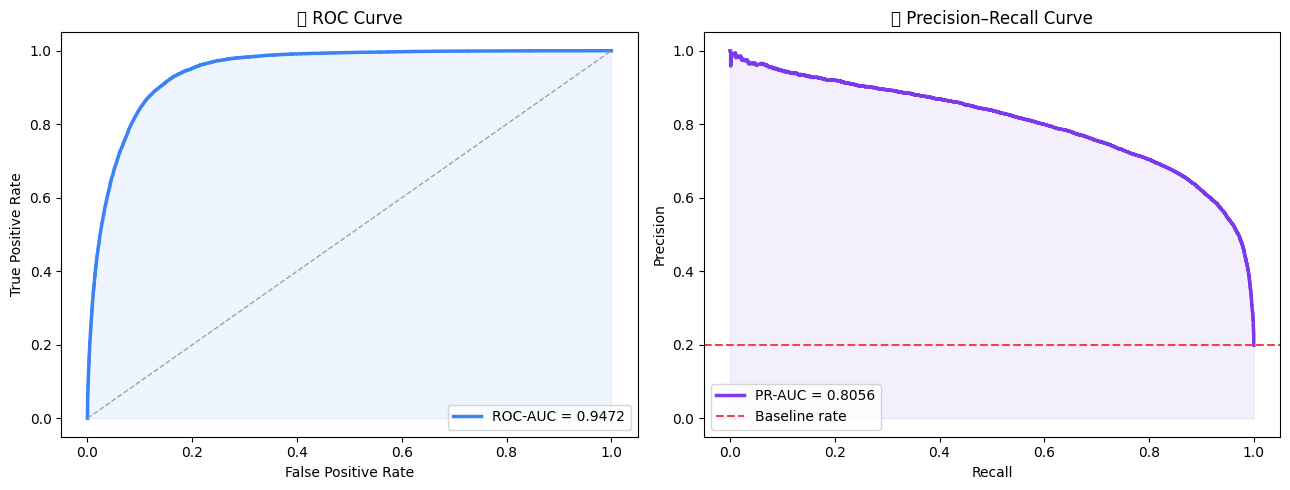

In [22]:
COLORS = {
    "blue": "#3B82F6",
    "purple": "#7C3AED",
    "red": "#EF4444",
}

# =================================================================================
# 💙 SAFE COLOR HANDLER (prevents KeyError)
# =================================================================================

def get_color(name, default="#3B82F6"):
    return COLORS.get(name, default)


from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score, average_precision_score

# =================================================================================
# CURVE DATA
# =================================================================================
fpr, tpr, _ = roc_curve(eval_y, valid_proba)
precision, recall, _ = precision_recall_curve(eval_y, valid_proba)

roc_auc = roc_auc_score(eval_y, valid_proba)
pr_auc = average_precision_score(eval_y, valid_proba)

# =================================================================================
# PLOT
# =================================================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 💙 ROC CURVE
axes[0].plot(
    fpr, tpr,
    color=get_color("blue"),
    linewidth=2.5,
    label=f"ROC-AUC = {roc_auc:.4f}"
)

axes[0].plot(
    [0, 1], [0, 1],
    linestyle="--",
    color=get_color("neutral", "#9CA3AF"),
    linewidth=1
)

axes[0].fill_between(fpr, tpr, alpha=0.08, color=get_color("blue"))

axes[0].set_title("💙 ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc="lower right")


# 💜 PR CURVE
axes[1].plot(
    recall, precision,
    color=get_color("purple"),
    linewidth=2.5,
    label=f"PR-AUC = {pr_auc:.4f}"
)

axes[1].axhline(
    eval_y.mean(),
    linestyle="--",
    color=get_color("red"),
    linewidth=1.5,
    label="Baseline rate"
)

axes[1].fill_between(recall, precision, alpha=0.08, color=get_color("purple"))

axes[1].set_title("💜 Precision–Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(loc="lower left")

plt.tight_layout()
plt.show()

### 9.2 Threshold Diagnostics (Not Submission Labels)

Threshold diagnostics are operational: they show how precision and recall would trade off if a team needed a hard decision rule. The competition submission should remain continuous probabilities.

0.350,67.60%,84.30%,75.04%,24.81%
0.400,69.87%,80.88%,74.97%,23.03%
0.300,65.13%,87.28%,74.60%,26.66%
0.450,71.92%,76.91%,74.33%,21.28%
0.250,62.39%,89.71%,73.59%,28.61%
0.500,74.26%,72.78%,73.51%,19.50%
0.200,59.55%,91.99%,72.30%,30.74%
0.550,76.64%,68.01%,72.07%,17.66%
0.150,56.41%,94.13%,70.55%,33.20%
0.600,78.87%,62.48%,69.73%,15.76%
0.100,52.98%,95.87%,68.25%,36.01%


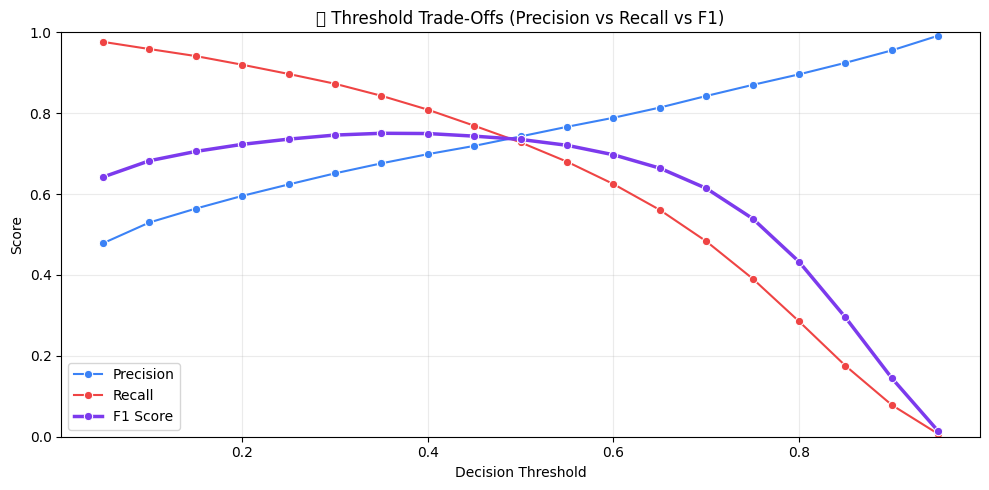

In [23]:
from sklearn.metrics import precision_score, recall_score, f1_score

# --- SAFE COLOR SYSTEM (prevents KeyError) ---
COLORS = globals().get("COLORS", {
    "blue": "#3B82F6",
    "purple": "#7C3AED",
    "red": "#EF4444",
    "neutral": "#9CA3AF"
})


threshold_rows = []

for threshold in np.linspace(0.05, 0.95, 19):

    pred = (valid_proba >= threshold).astype(int)

    threshold_rows.append({
        "Threshold": threshold,
        "Precision": precision_score(eval_y, pred, zero_division=0),
        "Recall": recall_score(eval_y, pred, zero_division=0),
        "F1": f1_score(eval_y, pred, zero_division=0),
        "Predicted_Positive_Rate": pred.mean(),
    })


threshold_table = pd.DataFrame(threshold_rows)

best_table = threshold_table.sort_values("F1", ascending=False)

display_table_card(
    "💛 Threshold Table (Sorted by F1)",
    best_table,
    index=False
)

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=threshold_table,
    x="Threshold",
    y="Precision",
    marker="o",
    color=COLORS["blue"],
    label="Precision"
)

sns.lineplot(
    data=threshold_table,
    x="Threshold",
    y="Recall",
    marker="o",
    color=COLORS["red"],
    label="Recall"
)

sns.lineplot(
    data=threshold_table,
    x="Threshold",
    y="F1",
    marker="o",
    color=COLORS["purple"],
    linewidth=2.5,
    label="F1 Score"
)

plt.title("💙 Threshold Trade-Offs (Precision vs Recall vs F1)")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

### 9.3 Linear Coefficient Direction Review

Coefficient direction is kept as an interpretability check for the transparent linear reference. The selected submission model may be the boosted tree or the blend, so this section should be read as model explanation rather than final-model attribution.


In [24]:

linear_reference = fitted_models.get("Linear Logistic")

# --- SAFE COLOR SYSTEM ---
COLORS = globals().get("COLORS", {
    "blue": "#3B82F6",
    "purple": "#7C3AED",
    "red": "#EF4444",
    "neutral": "#9CA3AF"
})


if linear_reference is not None:

    preprocess_step = linear_reference.named_steps["preprocess"]
    model_step = linear_reference.named_steps["model"]

    feature_names = preprocess_step.get_feature_names_out()

    coef_table = pd.DataFrame({
        "Encoded_Feature": feature_names,
        "Coefficient": model_step.coef_[0],
    })

    coef_table["Abs_Coefficient"] = coef_table["Coefficient"].abs()
    display_table_card(
        "💜 Strong Positive Drivers (Increase Pit Probability)",
        coef_table.sort_values("Coefficient", ascending=False).head(15),
        index=False
    )
    display_table_card(
        "❤️ Strong Negative Drivers (Decrease Pit Probability)",
        coef_table.sort_values("Coefficient", ascending=True).head(15),
        index=False
    )
    top_abs = coef_table.sort_values("Abs_Coefficient", ascending=False).head(15)

    display_table_card(
        "💙 Most Influential Linear Features (Magnitude)",
        top_abs,
        index=False
    )

else:

    display_kv(
        "Linear Coefficients",
        [("Status", "Linear Logistic model not fitted or not available")]
    )

num__EstimatedRaceLaps,1.1213,1.1213
cat__Race_Spanish Grand Prix,0.6899,0.6899
num__LapNumber,0.6408,0.6408
num__Stint×TyreLife,0.6335,0.6335
num__TyreLife,0.5763,0.5763
num__Stint,0.5527,0.5527
cat__Race_Bahrain Grand Prix,0.5144,0.5144
cat__Compound_SOFT,0.4889,0.4889
num__TyreLife×CompoundHardness,0.4842,0.4842
num__TyreLifeToLapNumber,0.3991,0.3991
cat__Compound_HARD,0.3158,0.3158


num__Stint×RaceProgress,-1.0624,1.0624
cat__Compound_MEDIUM,-0.6203,0.6203
num__StopUrgency,-0.5644,0.5644
num__RaceProgress×TyreLife,-0.5183,0.5183
cat__Race_Mexico City Grand Prix,-0.4872,0.4872
cat__Race_Canadian Grand Prix,-0.4064,0.4064
num__TyreLifeMinusLapNumber,-0.4024,0.4024
cat__Race_Australian Grand Prix,-0.2969,0.2969
cat__Race_Dutch Grand Prix,-0.2637,0.2637
cat__Race_Miami Grand Prix,-0.2501,0.2501
cat__Race_Austrian Grand Prix,-0.1859,0.1859


num__EstimatedRaceLaps,1.1213,1.1213
num__Stint×RaceProgress,-1.0624,1.0624
cat__Race_Spanish Grand Prix,0.6899,0.6899
num__LapNumber,0.6408,0.6408
num__Stint×TyreLife,0.6335,0.6335
cat__Compound_MEDIUM,-0.6203,0.6203
num__TyreLife,0.5763,0.5763
num__StopUrgency,-0.5644,0.5644
num__Stint,0.5527,0.5527
num__RaceProgress×TyreLife,-0.5183,0.5183
cat__Race_Bahrain Grand Prix,0.5144,0.5144


### 9.4 Build Test Predictions from the Selected Source

External stack/rank-blend predictions are reused directly when available. If the notebook selected the internal fallback, the selected model or blend is refit on all training rows before predicting test.


In [25]:
COLORS = globals().get("COLORS", {
    "blue": "#3B82F6",
    "purple": "#7C3AED",
    "red": "#EF4444",
    "yellow": "#FACC15",
    "neutral": "#9CA3AF"
})

if selected_strategy == "External Stack/Rank Blend":

    external_submission = pd.read_csv(external_stack_artifact["submission_path"])
    external_sub_col = next(c for c in TARGET_CANDIDATES if c in external_submission.columns)

    assert external_submission[ID_COL].equals(test[ID_COL])

    test_proba = external_submission[external_sub_col].to_numpy(dtype=float)

    final_model = {"External Artifact": str(external_stack_artifact["submission_path"])}

elif selected_strategy == "Validation Blend":

    final_linear_model = clone(model_candidates["Linear Logistic"])
    final_tree_model = clone(model_candidates["Boosted Trees"])

    final_linear_model.fit(X, y)
    final_tree_model.fit(X, y)

    linear_test_proba = final_linear_model.predict_proba(X_test)[:, 1]
    tree_test_proba = final_tree_model.predict_proba(X_test)[:, 1]

    test_proba = (
        (1 - selected_tree_weight) * linear_test_proba +
        selected_tree_weight * tree_test_proba
    )

    final_model = {
        "Linear Logistic": final_linear_model,
        "Boosted Trees": final_tree_model,
        "Tree_Weight": selected_tree_weight,
    }

else:

    final_model = clone(model_candidates[selected_strategy])
    final_model.fit(X, y)

    test_proba = final_model.predict_proba(X_test)[:, 1]
test_proba = np.clip(test_proba, 1e-6, 1 - 1e-6)

prediction_summary = (
    pd.Series(test_proba, name=TARGET)
    .describe()
    .rename_axis("Statistic")
    .reset_index(name="Probability")
)

strategy_summary = pd.DataFrame({
    "Item": [
        "Selected Strategy",
        "Tree Weight",
        "Validation ROC-AUC",
        "Validation PR-AUC",
        "Test Mean Probability",
    ],
    "Value": [
        selected_strategy,
        "" if pd.isna(selected_tree_weight) else f"{selected_tree_weight:.2f}",
        f"{model_comparison.loc[0, 'ROC-AUC']:.4f}",
        f"{model_comparison.loc[0, 'PR-AUC']:.4f}",
        f"{test_proba.mean():.4f}",
    ],
})

display_table_card(
    "💙💛 Selected Prediction Strategy",
    strategy_summary,
    index=False,
    max_width="520px"
)

display_table_card(
    "💛 Test Prediction Distribution",
    prediction_summary,
    index=False,
    max_width="420px"
)

Selected Strategy,Boosted Trees
Tree Weight,
Validation ROC-AUC,0.9472
Validation PR-AUC,0.8056
Test Mean Probability,0.1983


count,"188,165"
mean,0.198
std,0.288
min,0.000
25%,0.004
50%,0.023
75%,0.345
max,0.970


### 10. Write the Submission File

The final checks enforce the Kaggle contract: one row per test ID, no missing probabilities, and values bounded between 0 and 1.

In [26]:
submission = sample_submission.copy()
submission[TARGET] = test_proba

if submission.shape[0] != test.shape[0]:
    raise ValueError("Submission row count mismatch with test set.")

if not submission[ID_COL].equals(test[ID_COL]):
    raise ValueError("ID column mismatch between submission and test.")

if submission[TARGET].isna().sum() > 0:
    raise ValueError("NaN values found in prediction column.")

if not submission[TARGET].between(0, 1).all():
    raise ValueError("Predictions must be in [0, 1] range.")

submission.to_csv(SUBMISSION_FILENAME, index=False)

display_kv(
    "💙💛 Submission Output Summary",
    [
        ("File", SUBMISSION_FILENAME),
        ("Rows", f"{len(submission):,}"),
        ("Columns", ", ".join(submission.columns)),
        ("Min Probability", f"{submission[TARGET].min():.4f}"),
        ("Max Probability", f"{submission[TARGET].max():.4f}"),
        ("Mean Probability", f"{submission[TARGET].mean():.4f}"),
    ]
)

display_table_card(
    "💛 Submission Preview",
    submission.head(10),
    index=False
)

439140,0.006
439141,0.002
439142,0.003
439143,0.163
439144,0.843
439145,0.387
439146,0.001
439147,0.029
439148,0.040
439149,0.002


## 10. 🚀 Next Experiments

<div style="background: #FFFCF8; border: 1px solid #E2D8C7; border-radius: 16px; padding: 18px 20px; margin: 12px 0 20px 0; box-shadow: 0 8px 20px rgba(35, 49, 39, 0.04); color: #233127;">
  <div style="font-size: 1.25rem; font-weight: 900; margin-bottom: 8px; color:#233127;">From Transparent Baseline to Score-Oriented Modeling</div>
  <div style="font-size: 13px; color:#5F6B60; line-height:1.55; margin-bottom:14px;">The baseline is deliberately simple. Stronger versions should be built as ablations so each improvement can be measured instead of mixed together.</div>
  <div style="display:grid; grid-template-columns: repeat(auto-fit, minmax(235px, 1fr)); gap:12px;">
    <div style="border:1px solid #E4DAC9; border-radius:14px; padding:13px 14px; background:#F7F3EA;"><div style="font-weight:900; color:#2F6B4F; margin-bottom:6px;">Driver Ladder</div><div style="font-size:12.8px; line-height:1.55;">Compare no-Driver, Driver one-hot, frequency encoding, fold-safe target encoding, and Driver × Compound encodings.</div></div>
    <div style="border:1px solid #E4DAC9; border-radius:14px; padding:13px 14px; background:#F7F3EA;"><div style="font-weight:900; color:#3D6F8A; margin-bottom:6px;">External Boosters</div><div style="font-size:12.8px; line-height:1.55;">Try LightGBM, XGBoost, or CatBoost under the same validation split after the sklearn tree baseline is understood.</div></div>
    <div style="border:1px solid #E4DAC9; border-radius:14px; padding:13px 14px; background:#F7F3EA;"><div style="font-weight:900; color:#C7772C; margin-bottom:6px;">Original Data Ablation</div><div style="font-size:12.8px; line-height:1.55;">Test original rows with explicit sample weights because their target prior differs from the synthetic train set.</div></div>
    <div style="border:1px solid #E4DAC9; border-radius:14px; padding:13px 14px; background:#F7F3EA;"><div style="font-weight:900; color:#B5473C; margin-bottom:6px;">Validation Stress Tests</div><div style="font-size:12.8px; line-height:1.55;">Add race-year or group-aware splits to check whether gains survive beyond random stratified folds.</div></div>
    <div style="border:1px solid #E4DAC9; border-radius:14px; padding:13px 14px; background:#F7F3EA;"><div style="font-weight:900; color:#2F6B4F; margin-bottom:6px;">Calibration</div><div style="font-size:12.8px; line-height:1.55;">Use calibration curves or Brier/log-loss checks when probability quality matters more than pure ranking.</div></div>
    <div style="border:1px solid #E4DAC9; border-radius:14px; padding:13px 14px; background:#F7F3EA;"><div style="font-weight:900; color:#3D6F8A; margin-bottom:6px;">OOF Blending</div><div style="font-size:12.8px; line-height:1.55;">Blend only models that improve out-of-fold validation independently, then choose weights from OOF predictions.</div></div>
  </div>
</div>

## Thank you...pls upvote!!!!!!!!!